# 02 · RL Portfolio Environment

Gymnasium-compatible environment for PPO-based portfolio optimization.
One environment per risk profile (conservative / balanced / aggressive).

v5 architectural improvements:
  - VecEnv (DummyVecEnv) for richer rollout diversity during training
  - Multi-episode evaluation: all valid start indices in each eval window
  - Block bootstrap confidence intervals for Sharpe and annualized return
  - Walk-forward retraining: expanding windows across 2015-2026
  - Rolling evaluation windows with per-fold metric aggregation
  - EGX30 market regime signal in observation (MA20/MA60-1, from notebook 01)
  - CONIA delta signal in observation (60-day change in CBE overnight rate)
  - CVaR reported as per-period (not annualized) — interpretable tail metric
  - Proportional timesteps per fold: more training data → more steps
  - Dynamic universe filtering (Design B): profile_mask_tensor restricts
    tradeable stocks to those currently classified as RISK_PROFILE,
    updated semi-annually. N=31 fixed; off-profile stocks zeroed via mask.

## 1. Imports

In [1]:
from pathlib import Path
import json
import subprocess
import sys
import numpy as np
import pandas as pd
import torch
from scipy import stats
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import (
    EvalCallback,
    StopTrainingOnNoModelImprovement,
    BaseCallback,
)
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor

## 2. Configuration

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR      = Path("../../")
DATA_DIR      = BASE_DIR / "data"
TENSORS_DIR   = DATA_DIR / "processed/tensors"
METADATA_DIR  = DATA_DIR / "processed/metadata"

MARKET_DATA_PATH = BASE_DIR / "src/ingestion/cache/market_data.csv"
RRFR_SCRIPT_PATH = BASE_DIR / "src/ingestion/EGX30_RRFR.py"

In [3]:
# ── Version and profile ───────────────────────────────────────────────────────
VERSION      = "v3"
RISK_PROFILE = "conservative"

In [4]:
# ── Episode structure ─────────────────────────────────────────────────────────
EPISODE_LENGTH   = 36
REBALANCE_DAYS   = 21
PERIODS_PER_YEAR = 252 / 21

In [5]:
# ── Action space constraints ──────────────────────────────────────────────────
MAX_CASH_WEIGHT  = 0.30
MAX_STOCK_WEIGHT = 0.20
MIN_STOCK_WEIGHT = 0.0

In [6]:
# ── Transaction costs ─────────────────────────────────────────────────────────
BASE_TRANSACTION_COST = 0.0064
MAX_TRANSACTION_COST  = 0.015

In [7]:
# ── VecEnv parallelism ────────────────────────────────────────────────────────
N_ENVS = 4

In [8]:
# ── Walk-forward configuration ────────────────────────────────────────────────
WALK_FORWARD_FOLDS = [
    {"name": "fold_1", "train_end": "2019-12-31", "val_end": "2020-12-31", "test_end": "2021-12-31"},
    {"name": "fold_2", "train_end": "2020-12-31", "val_end": "2021-12-31", "test_end": "2022-12-31"},
    {"name": "fold_3", "train_end": "2021-12-31", "val_end": "2022-12-31", "test_end": "2023-12-31"},
    {"name": "fold_4", "train_end": "2022-12-31", "val_end": "2023-12-31", "test_end": "2026-06-04"},
]

BASE_TIMESTEPS = 5_000_000

In [9]:
# ── Multi-episode evaluation ──────────────────────────────────────────────────
MAX_EVAL_EPISODES = 50

# ── Block bootstrap ───────────────────────────────────────────────────────────
N_BOOTSTRAP      = 2000
BOOTSTRAP_BLOCK  = 3
CONFIDENCE_LEVEL = 0.95

In [10]:
PPO_PARAMS = {
    "policy":          "MlpPolicy",
    "learning_rate":   1e-4,
    "n_steps":         4096,
    "batch_size":      64,
    "n_epochs":        10,
    "gamma":           0.999,
    "gae_lambda":      0.95,
    "clip_range":      0.2,
    "ent_coef":        0.02,
    "vf_coef":         0.5,
    "max_grad_norm":   0.5,
    "verbose":         0,
    "policy_kwargs": {
        "net_arch":      [256, 256, 256],
        "activation_fn": __import__("torch.nn", fromlist=["Tanh"]).Tanh,
    },
}

In [11]:
REWARD_CONFIGS = {
    "conservative": {
    "return_weight":    1.0,
    "turnover_penalty": 0.001,
    "downside_penalty": 1.0,
    "drawdown_penalty": 1.5,
    "hhi_penalty":      0.5,
    "cash_penalty":     0.5,
},
    "balanced": {
        "return_weight":    1.0,
        "turnover_penalty": 0.01,
        "downside_penalty": 0.8,
        "drawdown_penalty": 1.0,
        "hhi_penalty":      0.3,
        "cash_penalty":     2.0,
    },
    "aggressive": {
        "return_weight":    1.0,
        "turnover_penalty": 0.002,
        "downside_penalty": 0.0,
        "drawdown_penalty": 0.0,
        "hhi_penalty":      0.1,
        "cash_penalty":     3.0,
    },
}

In [12]:
PALETTE = {
    "primary":   "#2c7bb6",
    "secondary": "#d7191c",
    "tertiary":  "#fdae61",
    "accent":    "#abd9e9",
    "train":     "#2c7bb6",
    "val":       "#fdae61",
    "test":      "#2ca25f",
    "alert":     "#d7191c",
}

## 3. Risk-Free Rate (CBE CONIA)

In [13]:
print("Fetching risk-free rate from CBE...")

try:
    result = subprocess.run(
        ["python", str(RRFR_SCRIPT_PATH)],
        capture_output=True, text=True, timeout=60
    )
    if result.returncode != 0:
        raise RuntimeError(result.stderr)

    market_df = pd.read_csv(MARKET_DATA_PATH)
    market_df["conia_date"] = pd.to_datetime(market_df["conia_date"])
    latest_row = market_df.sort_values("conia_date").iloc[-1]

    ANNUAL_RISK_FREE_RATE = float(latest_row["conia_value"])
    conia_date            = latest_row["conia_date"].date()
    print(f"✓ CONIA loaded : {ANNUAL_RISK_FREE_RATE*100:.2f}% (as of {conia_date})")

except Exception as e:
    ANNUAL_RISK_FREE_RATE = 0.21
    print(f"⚠ RRFR script failed: {e}")
    print(f"  Using fallback rate: {ANNUAL_RISK_FREE_RATE*100:.2f}%")

PERIOD_RISK_FREE_RATE = (1 + ANNUAL_RISK_FREE_RATE) ** (21 / 252) - 1
print(f"  Annual rate     : {ANNUAL_RISK_FREE_RATE*100:.2f}%")
print(f"  Per-period rate : {PERIOD_RISK_FREE_RATE*100:.4f}%  (21-day equivalent)")

Fetching risk-free rate from CBE...


⚠ RRFR script failed: Traceback (most recent call last):
  File "C:\Users\youssef\Desktop\Portfolio_Personalization\src\ingestion\EGX30_RRFR.py", line 18, in <module>
    from selenium import webdriver
ModuleNotFoundError: No module named 'selenium'

  Using fallback rate: 21.00%
  Annual rate     : 21.00%
  Per-period rate : 1.6012%  (21-day equivalent)


## 4. Load Artifacts

In [14]:
feature_tensor = torch.load(
    TENSORS_DIR / "feature_tensor.pt", weights_only=False
).numpy()

returns_tensor = torch.load(
    TENSORS_DIR / "returns_tensor.pt", weights_only=False
).numpy()

mask_tensor = torch.load(
    TENSORS_DIR / "mask_tensor.pt", weights_only=False
).numpy()

# ── Market regime signal ──────────────────────────────────────────────────────
# Shape [T, 2]: col0=egx30_ma_ratio, col1=conia_delta
# Produced by notebook 01. Same value for all stocks on a given day.
market_signal = torch.load(
    TENSORS_DIR / "market_signal.pt", weights_only=False
).numpy()

# ── Profile mask tensor ───────────────────────────────────────────────────────
# Shape [T, N]: 1 = stock classified as RISK_PROFILE on this day, 0 = excluded
# Produced by notebook 01 from daily_risk_classifications.csv.
# Combined with availability mask at each step for dynamic universe filtering.
profile_mask_tensor = torch.load(
    TENSORS_DIR / "profile_mask_tensor.pt", weights_only=False
).numpy()

In [15]:
with open(METADATA_DIR / "feature_names.json") as f:
    feature_names = json.load(f)

with open(METADATA_DIR / "split_indices.json") as f:
    global_split_indices = json.load(f)

with open(METADATA_DIR / "meta.json") as f:
    meta = json.load(f)

with open(METADATA_DIR / "date_index.json") as f:
    date_index = json.load(f)

with open(METADATA_DIR / "market_signal_stats.json") as f:
    market_signal_stats = json.load(f)

In [16]:
print(f"Feature tensor  : {feature_tensor.shape}  (T, N_stocks, N_features)")
print(f"Returns tensor  : {returns_tensor.shape}  (T, N_stocks)")
print(f"Mask tensor     : {mask_tensor.shape}  (T, N_stocks)")
print(f"Market signal   : {market_signal.shape}  (T, 2)  "
      f"egx30=[{market_signal[:,0].min():.3f}, {market_signal[:,0].max():.3f}]  "
      f"conia=[{market_signal[:,1].min():.3f}, {market_signal[:,1].max():.3f}]")
print(f"Profile mask    : {profile_mask_tensor.shape}  "
      f"coverage={profile_mask_tensor.mean()*100:.1f}% ({RISK_PROFILE})")
print(f"Date range      : {date_index[0]} to {date_index[-1]}")
print(f"Tickers         : {meta['n_stocks']}")

assert market_signal.shape[0] == feature_tensor.shape[0], \
    "market_signal T dimension must match feature_tensor T dimension"
assert not np.isnan(market_signal).any(), \
    "market_signal contains NaN — check notebook 01 trimming"
assert market_signal.shape[1] == 2, \
    f"Expected 2 market signals, got {market_signal.shape[1]}"
assert profile_mask_tensor.shape == mask_tensor.shape, \
    f"Profile mask shape {profile_mask_tensor.shape} != mask tensor shape {mask_tensor.shape}"

print(f"\nAll tensors loaded and validated.")

Feature tensor  : (2647, 54, 9)  (T, N_stocks, N_features)
Returns tensor  : (2647, 54)  (T, N_stocks)
Mask tensor     : (2647, 54)  (T, N_stocks)
Market signal   : (2647, 2)  (T, 2)  egx30=[-4.067, 6.523]  conia=[0.000, 0.000]
Profile mask    : (2647, 54)  coverage=16.7% (conservative)
Date range      : 2015-07-06 to 2026-06-04
Tickers         : 54

All tensors loaded and validated.


In [17]:
date_to_idx = {d: i for i, d in enumerate(date_index)}

## 5. Universe (All Tickers — Profile Filtering via Mask)

In [18]:
all_tickers      = meta["tickers"]
universe_tickers = sorted(all_tickers)   # all 31 — profile filtering via profile_mask_tensor
universe_indices = list(range(len(all_tickers)))
REL_VOL_IDX      = feature_names.index("rel_volume")

print(f"Universe : {len(universe_tickers)} stocks (all tickers)")
print(f"Profile filtering applied dynamically at each step via profile_mask_tensor")
print(f"Tickers  : {universe_tickers}")

Universe : 54 stocks (all tickers)
Profile filtering applied dynamically at each step via profile_mask_tensor
Tickers  : ['ABUK', 'ADIB', 'AMOC', 'ARAB', 'ARCC', 'ASPI', 'BINV', 'BTFH', 'CCAP', 'CICH', 'CIEB', 'CIRA', 'CLHO', 'COMI', 'DSCW', 'EAST', 'EFID', 'EFIH', 'EGAL', 'EGCH', 'EGTS', 'EMFD', 'ETEL', 'EXPA', 'FAIT', 'FAITA', 'FWRY', 'GBCO', 'GDWA', 'HDBK', 'HELI', 'HRHO', 'ISPH', 'JUFO', 'MCQE', 'MFPC', 'MTIE', 'OCDI', 'OFH', 'OIH', 'ORAS', 'ORHD', 'ORWE', 'PHAR', 'PHDC', 'RAYA', 'RMDA', 'SKPC', 'SPMD', 'SUGR', 'TALM', 'TMGH', 'VLMR', 'VLMRA']


## 6. PortfolioEnv Class

In [19]:
class PortfolioEnv(gym.Env):
    """
    Gymnasium-compatible portfolio optimization environment.

    Observation vector layout:
        [0 : N*F]            per-stock features, flattened (N x F numbers)
        [N*F : N*F+N]        current stock weights          (N numbers)
        [N*F+N]              current cash weight             (1 number)
        [N*F+N+1 : N*F+N+3] market signals                  (2 numbers)
                             col0=egx30_ma_ratio, col1=conia_delta
        Total: N*F + N + 1 + 2

    Dynamic universe filtering (Design B):
        combined_mask = availability_mask & profile_mask
        Stocks failing either check are zeroed and forced to zero weight.
        N stays fixed at 31 — no architecture change needed between profiles
        or semi-annual classification updates.
    """

    def __init__(
        self,
        feature_tensor,
        returns_tensor,
        mask_tensor,
        market_signal,
        profile_mask_tensor,
        universe_indices,
        split_indices,
        risk_profile,
        feature_names,
        mode="train",
        episode_length=24,
        rebalance_days=21,
        silent=False,
    ):
        super().__init__()

        self.feature_tensor      = feature_tensor
        self.returns_tensor      = returns_tensor
        self.mask_tensor         = mask_tensor
        self.market_signal       = market_signal
        self.profile_mask_tensor = profile_mask_tensor
        self.universe_indices    = universe_indices
        self.feature_names       = feature_names
        self.risk_profile        = risk_profile
        self.mode                = mode
        self.episode_length      = episode_length
        self.rebalance_days      = rebalance_days

        self.N = len(universe_indices)
        self.F = feature_tensor.shape[2]
        self.T = feature_tensor.shape[0]

        self.reward_cfg  = REWARD_CONFIGS[risk_profile]
        self.rel_vol_idx = REL_VOL_IDX

        rows_needed = episode_length * rebalance_days
        available   = split_indices[mode]
        self.valid_starts = [
            i for i in available
            if i + rows_needed < self.T
        ]

        obs_dim = self.N * self.F + self.N + 1 + 2
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32
        )
        self.action_space = spaces.Box(
            low=-10.0, high=10.0, shape=(self.N + 1,), dtype=np.float32
        )

        if not silent:
            print(f"PortfolioEnv [{mode}] : {self.N} stocks | "
                  f"{len(self.valid_starts)} valid starts | "
                  f"obs=({obs_dim},) = {self.N}x{self.F} features "
                  f"+ {self.N} stock weights + 1 cash + 2 market signals")

        self.current_step    = 0
        self.start_idx       = 0
        self.current_weights = np.zeros(self.N + 1, dtype=np.float32)
        self.portfolio_value = 1.0
        self.peak_value      = 1.0
        self.episode_returns = []

    def _get_combined_mask(self, day_idx):
        """
        Combines availability mask with profile mask.
        A stock is tradeable only if it has price data AND
        is currently classified as this risk profile.
        """
        avail_mask   = self.mask_tensor[day_idx, self.universe_indices]
        profile_mask = self.profile_mask_tensor[day_idx, self.universe_indices]
        return (avail_mask * profile_mask).astype(np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        if options is not None and "start_idx" in options:
            self.start_idx = options["start_idx"]
        elif self.mode == "train":
            self.start_idx = int(np.random.choice(self.valid_starts))
        else:
            self.start_idx = self.valid_starts[0]

        self.current_step    = 0
        self.portfolio_value = 1.0
        self.peak_value      = 1.0
        self.episode_returns = []
        self.current_weights = np.full(
            self.N + 1, 1.0 / (self.N + 1), dtype=np.float32
        )

        return self._get_observation(), {}

    def _get_observation(self):
        day_idx = self.start_idx + self.current_step * self.rebalance_days

        # Combined mask: available AND in profile
        combined_mask  = self._get_combined_mask(day_idx)
        stock_features = self.feature_tensor[day_idx, self.universe_indices, :]
        stock_features = stock_features * combined_mask[:, np.newaxis]

        regime_signal = self.market_signal[day_idx].astype(np.float32)  # shape [2]

        return np.concatenate([
            stock_features.flatten(),
            self.current_weights[:-1],
            self.current_weights[-1:],
            regime_signal,
        ]).astype(np.float32)

    def _apply_position_limits(self, weights, stock_mask):
        stock_weights = weights[:-1].copy()
        for _ in range(10):
            if not (stock_weights > MAX_STOCK_WEIGHT).any():
                break
            for i in range(len(stock_weights)):
                if stock_weights[i] > MAX_STOCK_WEIGHT:
                    excess           = stock_weights[i] - MAX_STOCK_WEIGHT
                    stock_weights[i] = MAX_STOCK_WEIGHT
                    eligible = np.array([
                        j for j in range(len(stock_weights))
                        if j != i and stock_mask[j] == 1
                        and stock_weights[j] < MAX_STOCK_WEIGHT
                    ])
                    if len(eligible) > 0:
                        s = stock_weights[eligible].sum()
                        if s > 1e-8:
                            stock_weights[eligible] += excess * (
                                stock_weights[eligible] / s
                            )
                        else:
                            stock_weights[eligible] += excess / len(eligible)
                    else:
                        weights[-1] += excess
        weights[:-1] = stock_weights
        return weights

    def _liquidity_adjusted_cost(self, day_idx, stock_turnover):
        rel_vol = self.feature_tensor[
            day_idx, self.universe_indices, self.rel_vol_idx
        ]
        max_mult       = MAX_TRANSACTION_COST / BASE_TRANSACTION_COST
        liquidity_mult = np.clip(1.0 - 0.3 * rel_vol, 1.0, max_mult)
        per_stock_cost = BASE_TRANSACTION_COST * liquidity_mult
        return float(np.dot(np.abs(stock_turnover), per_stock_cost))

    def step(self, action):
        action      = np.array(action, dtype=np.float32)
        exp_action  = np.exp(action - action.max())
        raw_weights = exp_action / exp_action.sum()

        day_idx    = self.start_idx + self.current_step * self.rebalance_days
        stock_mask = self._get_combined_mask(day_idx)  # combined availability + profile
        raw_weights[:-1] *= stock_mask

        weight_sum = raw_weights.sum()
        if weight_sum > 1e-8:
            raw_weights = raw_weights / weight_sum
        else:
            raw_weights     = np.zeros(self.N + 1, dtype=np.float32)
            raw_weights[-1] = 1.0

        if raw_weights[-1] > MAX_CASH_WEIGHT:
            excess          = raw_weights[-1] - MAX_CASH_WEIGHT
            raw_weights[-1] = MAX_CASH_WEIGHT
            stock_sum       = raw_weights[:-1].sum()
            if stock_sum > 1e-8:
                raw_weights[:-1] += excess * (raw_weights[:-1] / stock_sum)
            else:
                valid_idx = np.where(stock_mask == 1)[0]
                if len(valid_idx) > 0:
                    raw_weights[valid_idx] += excess / len(valid_idx)
                else:
                    raw_weights[-1] = 1.0
            s = raw_weights.sum()
            if s > 1e-8:
                raw_weights = raw_weights / s

        raw_weights = self._apply_position_limits(raw_weights, stock_mask)

        s = raw_weights.sum()
        new_weights = raw_weights / s if s > 1e-8 else (
            np.zeros(self.N + 1, dtype=np.float32) + [0.0] * self.N + [1.0]
        )

        stock_turnover = new_weights[:-1] - self.current_weights[:-1]
        cash_turnover  = abs(new_weights[-1] - self.current_weights[-1])
        turnover       = float(np.sum(np.abs(stock_turnover)) + cash_turnover)

        transaction_cost = self._liquidity_adjusted_cost(day_idx, stock_turnover)

        period_returns    = self.returns_tensor[
            day_idx:day_idx + self.rebalance_days, self.universe_indices
        ]
        stock_returns_21d = period_returns.sum(axis=0) * stock_mask
        portfolio_return  = float(np.dot(new_weights[:-1], stock_returns_21d))
        net_return        = portfolio_return - transaction_cost

        self.portfolio_value *= np.exp(net_return)
        self.peak_value       = max(self.peak_value, self.portfolio_value)
        self.episode_returns.append(net_return)

        reward  = self.reward_cfg["return_weight"] * net_return
        reward -= self.reward_cfg["turnover_penalty"] * turnover
        if self.reward_cfg["downside_penalty"] > 0 and net_return < 0:
            reward -= self.reward_cfg["downside_penalty"] * abs(net_return)
        current_drawdown = (self.peak_value - self.portfolio_value) / self.peak_value
        reward -= self.reward_cfg["drawdown_penalty"] * current_drawdown
        hhi     = float(np.sum(new_weights[:-1] ** 2))
        reward -= self.reward_cfg["hhi_penalty"] * hhi

        # ── Cash opportunity cost ─────────────────────────────────────────────
        regime_signal_val = float(self.market_signal[day_idx, 0])  # egx30_ma_ratio only
        if regime_signal_val > 0 and self.reward_cfg.get("cash_penalty", 0) > 0:
            excess_cash = max(0.0, new_weights[-1] - 0.10)
            reward -= self.reward_cfg["cash_penalty"] * regime_signal_val * excess_cash

        self.current_weights = new_weights
        self.current_step   += 1

        terminated = False
        truncated  = self.current_step >= self.episode_length
        obs = self._get_observation() if not truncated else \
              np.zeros(self.observation_space.shape, dtype=np.float32)

        info = {
            "portfolio_value":  self.portfolio_value,
            "portfolio_return": portfolio_return,
            "net_return":       net_return,
            "transaction_cost": transaction_cost,
            "turnover":         turnover,
            "drawdown":         current_drawdown,
            "hhi":              hhi,
            "current_weights":  new_weights.tolist(),
            "step":             self.current_step,
        }

        return obs, float(reward), terminated, truncated, info

    def close(self):
        pass

## 7. Walk-Forward Fold Index Builder

In [20]:
def build_fold_split_indices(fold):
    dates_pd = pd.to_datetime(date_index)

    train_mask = dates_pd <= fold["train_end"]
    val_mask   = (dates_pd > fold["train_end"]) & (dates_pd <= fold["val_end"])
    test_mask  = (dates_pd > fold["val_end"])   & (dates_pd <= fold["test_end"])

    train_idx = list(np.where(train_mask)[0])
    val_idx   = list(np.where(val_mask)[0])
    test_idx  = list(np.where(test_mask)[0])

    print(f"  Fold {fold['name']}:")
    print(f"    Train : {date_index[train_idx[0]]} → {date_index[train_idx[-1]]} "
          f"({len(train_idx)} days)")
    print(f"    Val   : {date_index[val_idx[0]]} → {date_index[val_idx[-1]]} "
          f"({len(val_idx)} days)")
    print(f"    Test  : {date_index[test_idx[0]]} → {date_index[test_idx[-1]]} "
          f"({len(test_idx)} days)")

    return {"train": train_idx, "val": val_idx, "test": test_idx}

print("Walk-forward fold index ranges:")
fold_split_indices = {}
for fold in WALK_FORWARD_FOLDS:
    fold_split_indices[fold["name"]] = build_fold_split_indices(fold)

_fold1_train_days = len(fold_split_indices["fold_1"]["train"])
print(f"\nBaseline train days (fold_1): {_fold1_train_days}")
for fold in WALK_FORWARD_FOLDS:
    n = len(fold_split_indices[fold["name"]]["train"])
    ts = int(BASE_TIMESTEPS * n / _fold1_train_days)
    print(f"  {fold['name']}: {n} train days → {ts:,} timesteps "
          f"(×{n/_fold1_train_days:.2f})")

Walk-forward fold index ranges:
  Fold fold_1:
    Train : 2015-07-06 → 2019-12-31 (1092 days)
    Val   : 2020-01-02 → 2020-12-31 (243 days)
    Test  : 2021-01-03 → 2021-12-30 (244 days)
  Fold fold_2:
    Train : 2015-07-06 → 2020-12-31 (1335 days)
    Val   : 2021-01-03 → 2021-12-30 (244 days)
    Test  : 2022-01-02 → 2022-12-29 (244 days)
  Fold fold_3:
    Train : 2015-07-06 → 2021-12-30 (1579 days)
    Val   : 2022-01-02 → 2022-12-29 (244 days)
    Test  : 2023-01-02 → 2023-12-31 (242 days)
  Fold fold_4:
    Train : 2015-07-06 → 2022-12-29 (1823 days)
    Val   : 2023-01-02 → 2023-12-31 (242 days)
    Test  : 2024-01-02 → 2026-06-04 (582 days)

Baseline train days (fold_1): 1092
  fold_1: 1092 train days → 5,000,000 timesteps (×1.00)
  fold_2: 1335 train days → 6,112,637 timesteps (×1.22)
  fold_3: 1579 train days → 7,229,853 timesteps (×1.45)
  fold_4: 1823 train days → 8,347,069 timesteps (×1.67)


## 8. Callbacks

In [21]:
class RewardLoggerCallback(BaseCallback):
    def __init__(self, log_path, verbose=0):
        super().__init__(verbose)
        self.log_path        = log_path
        self.episode_rewards = []
        self.episode_lengths = []
        self.episode_count   = 0
        self._saved          = False

    def _on_step(self):
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self.episode_rewards.append(info["episode"]["r"])
                self.episode_lengths.append(info["episode"]["l"])
                self.episode_count += 1
                if self.verbose > 0 and self.episode_count % 200 == 0:
                    recent = self.episode_rewards[-200:]
                    sys.__stdout__.write(
                        f"  Episode {self.episode_count:>6} | "
                        f"Mean reward (last 200): {np.mean(recent):>8.4f} | "
                        f"Std: {np.std(recent):>6.4f}\n"
                    )
                    sys.__stdout__.flush()
        return True

    def _on_training_end(self):
        if self._saved or not self.episode_rewards:
            return
        pd.DataFrame({
            "episode":        range(1, len(self.episode_rewards) + 1),
            "episode_reward": self.episode_rewards,
            "episode_length": self.episode_lengths,
        }).to_csv(self.log_path, index=False)
        sys.__stdout__.write(f"\nTraining history saved: {self.log_path}\n")
        sys.__stdout__.write(f"Total episodes : {self.episode_count}\n")
        sys.__stdout__.write(
            f"Final mean reward (last 200): "
            f"{np.mean(self.episode_rewards[-200:]):.4f}\n"
        )
        sys.__stdout__.flush()
        self._saved = True


class TrainingMetricsCallback(BaseCallback):
    def __init__(self, print_every_n_updates=20, verbose=1):
        super().__init__(verbose)
        self.print_every_n_updates = print_every_n_updates
        self.update_count          = 0

    def _on_rollout_end(self):
        self.update_count += 1
        if self.update_count % self.print_every_n_updates != 0:
            return True

        def get_metric(key):
            try:
                return self.model.logger.name_to_value.get(key, None)
            except Exception:
                return None

        ev = get_metric("train/explained_variance")
        cf = get_metric("train/clip_fraction")
        vl = get_metric("train/value_loss")
        ts = self.num_timesteps

        parts = [f"  [{ts:>7,} steps | update {self.update_count:>4}]"]
        if ev is not None: parts.append(f"explained_var={ev:>6.3f}")
        if cf is not None: parts.append(f"clip_frac={cf:>5.3f}")
        if vl is not None: parts.append(f"value_loss={vl:>7.4f}")
        sys.__stdout__.write("  | ".join(parts) + "\n")
        sys.__stdout__.flush()
        return True

    def _on_step(self):
        return True


class EvalWithStopCallback(EvalCallback):
    def __init__(self, stop_callback, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.stop_callback = stop_callback

    def _on_step(self):
        continue_training = super()._on_step()
        if self.eval_freq > 0 and self.n_calls % self.eval_freq == 0:
            self.stop_callback.n_calls       = self.n_calls
            self.stop_callback.num_timesteps = self.num_timesteps
            self.stop_callback.parent        = self
            self.stop_callback.model         = self.model
            continue_training = continue_training and self.stop_callback._on_step()
        return continue_training

## 9. Helper Functions

In [22]:
def compute_metrics(returns_arr, label, rfr=PERIOD_RISK_FREE_RATE,
                    ann_rfr=ANNUAL_RISK_FREE_RATE, print_results=True):
    """
    Performance metrics from 21-day period returns.

    Annualized: return, vol, Sharpe, Sortino (multiply by 12 or sqrt(12)).
    Per-period: CVaR (95%) — NOT annualized. CVaR is a single-period tail
    measure; annualizing it is misleading because it implies compounding of
    a tail event, which doesn't make economic sense.

    CVaR interpretation: "in the worst 5% of 21-day periods, the average
    loss was X%". This is directly comparable across strategies regardless
    of evaluation window length.
    """
    if len(returns_arr) == 0:
        return {}

    excess_returns = returns_arr - rfr
    ann_return     = returns_arr.mean() * PERIODS_PER_YEAR
    ann_vol        = returns_arr.std()  * np.sqrt(PERIODS_PER_YEAR)
    sharpe         = (ann_return - ann_rfr) / (ann_vol + 1e-8)

    downside_ex = excess_returns[excess_returns < 0]
    sortino_vol = downside_ex.std() * np.sqrt(PERIODS_PER_YEAR) \
                  if len(downside_ex) > 0 else 1e-8
    sortino     = (ann_return - ann_rfr) / (sortino_vol + 1e-8)

    cum_values = np.exp(np.cumsum(returns_arr))
    peak       = np.maximum.accumulate(cum_values)
    drawdowns  = (peak - cum_values) / peak
    max_dd     = drawdowns.max()
    calmar     = ann_return / max_dd if max_dd > 0.001 else np.nan

    # CVaR (95%) — per-period, not annualized
    var_95  = np.percentile(returns_arr, 5)
    mask_95 = returns_arr <= var_95
    cvar_95 = returns_arr[mask_95].mean() if mask_95.any() else np.nan

    # Win rate — % of periods with positive excess return over risk-free
    win_rate = float((returns_arr > rfr).mean())

    if print_results:
        print(f"\n-- {label} --")
        print(f"  N returns             : {len(returns_arr)}")
        print(f"  Annualized return     : {ann_return*100:>8.2f}%")
        print(f"  Risk-free (CONIA)     : {ann_rfr*100:>8.2f}%")
        print(f"  Annualized vol        : {ann_vol*100:>8.2f}%")
        print(f"  Sharpe ratio          : {sharpe:>8.3f}")
        print(f"  Sortino ratio         : {sortino:>8.3f}")
        print(f"  Max drawdown          : {max_dd*100:>8.2f}%")
        print(f"  Calmar ratio          : {calmar:>8.3f}" if not np.isnan(calmar)
              else f"  Calmar ratio          :      N/A")
        print(f"  CVaR (95%, per-period): {cvar_95*100:>7.2f}%"
              if not np.isnan(cvar_95) else
              f"  CVaR (95%, per-period):     N/A")
        print(f"  Win rate vs RFR       : {win_rate*100:>7.1f}%  "
              f"({int(win_rate * len(returns_arr))}/{len(returns_arr)} periods)")

    return {
        "label":      label,
        "n":          len(returns_arr),
        "ann_return": ann_return,
        "ann_vol":    ann_vol,
        "sharpe":     sharpe,
        "sortino":    sortino,
        "max_dd":     max_dd,
        "calmar":     calmar,
        "cvar_95":    cvar_95,
        "win_rate":   win_rate,
    }

def block_bootstrap_ci(returns_arr, stat_fn, n_bootstrap=N_BOOTSTRAP,
                        block_size=BOOTSTRAP_BLOCK, ci=CONFIDENCE_LEVEL):
    n = len(returns_arr)
    if n < block_size * 2:
        return np.nan, np.nan

    n_blocks   = int(np.ceil(n / block_size))
    boot_stats = []

    for _ in range(n_bootstrap):
        starts    = np.random.randint(0, n, size=n_blocks)
        resampled = np.concatenate([
            np.roll(returns_arr, -s)[:block_size] for s in starts
        ])[:n]
        try:
            boot_stats.append(stat_fn(resampled))
        except Exception:
            continue

    boot_stats = np.array([s for s in boot_stats if np.isfinite(s)])
    if len(boot_stats) < 10:
        return np.nan, np.nan

    alpha = 1 - ci
    return (np.percentile(boot_stats, 100 * alpha / 2),
            np.percentile(boot_stats, 100 * (1 - alpha / 2)))


def compute_bootstrap_cis(returns_arr, label, print_results=True):
    def sharpe_fn(r):
        ann_r = r.mean() * PERIODS_PER_YEAR
        ann_v = r.std()  * np.sqrt(PERIODS_PER_YEAR)
        return (ann_r - ANNUAL_RISK_FREE_RATE) / (ann_v + 1e-8)

    def ann_return_fn(r):
        return r.mean() * PERIODS_PER_YEAR

    def cvar_fn(r):
        var_95 = np.percentile(r, 5)
        tail   = r[r <= var_95]
        return tail.mean() if len(tail) > 0 else np.nan

    sharpe_lo, sharpe_hi = block_bootstrap_ci(returns_arr, sharpe_fn)
    ret_lo,    ret_hi    = block_bootstrap_ci(returns_arr, ann_return_fn)
    cvar_lo,   cvar_hi   = block_bootstrap_ci(returns_arr, cvar_fn)

    if print_results:
        print(f"\n  Bootstrap CIs ({int(CONFIDENCE_LEVEL*100)}%, "
              f"block={BOOTSTRAP_BLOCK}, n={N_BOOTSTRAP}) — {label}")
        print(f"    Ann. return          : [{ret_lo*100:+.2f}%, {ret_hi*100:+.2f}%]")
        print(f"    Sharpe               : [{sharpe_lo:+.3f},  {sharpe_hi:+.3f}]")
        print(f"    CVaR 95% (per-period): [{cvar_lo*100:+.2f}%, {cvar_hi*100:+.2f}%]")

    return {
        "sharpe_ci": (sharpe_lo, sharpe_hi),
        "ret_ci":    (ret_lo, ret_hi),
        "cvar_ci":   (cvar_lo, cvar_hi),
    }


def significance_test(rl_returns, eq_returns, label=""):
    rl_excess = rl_returns - PERIOD_RISK_FREE_RATE
    eq_excess = eq_returns - PERIOD_RISK_FREE_RATE
    diff      = rl_excess - eq_excess

    t_stat, t_pval = stats.ttest_1samp(diff, 0)
    try:
        w_stat, w_pval = stats.wilcoxon(diff)
    except Exception:
        w_stat, w_pval = np.nan, np.nan

    direction = "outperforms" if t_stat > 0 else "underperforms"
    print(f"\n  Statistical tests ({label}):")
    print(f"    H0: RL excess return == equal-weight excess return")
    print(f"    t-test  : t={t_stat:+.3f}  p={t_pval:.4f}  "
          f"{'✓ significant' if t_pval < 0.05 else '✗ not significant'} at 5%"
          f"  [{direction} EQW]")
    print(f"    Wilcoxon: W={w_stat:.1f}  p={w_pval:.4f}  "
          f"{'✓ significant' if w_pval < 0.05 else '✗ not significant'} at 5%")

    return {"t_stat": t_stat, "t_pval": t_pval,
            "w_stat": w_stat, "w_pval": w_pval,
            "direction": direction}

def compute_active_metrics(
        rl_returns,
        eq_returns,
        model,               # ← pass the fold model
        env_template,
        split_indices,
        mode,
        episode_length,
        fold_name,
        max_episodes=MAX_EVAL_EPISODES,
        print_results=True,
    ):
    n_common     = min(len(rl_returns), len(eq_returns))
    active_returns = rl_returns[:n_common] - eq_returns[:n_common]
    ir = float(active_returns.mean() / (active_returns.std() + 1e-8)) * \
         np.sqrt(PERIODS_PER_YEAR)
    win_rate_vs_eq = float((rl_returns[:n_common] > eq_returns[:n_common]).mean())

    eval_env = PortfolioEnv(
        feature_tensor      = env_template.feature_tensor,
        returns_tensor      = env_template.returns_tensor,
        mask_tensor         = env_template.mask_tensor,
        market_signal       = env_template.market_signal,
        profile_mask_tensor = env_template.profile_mask_tensor,
        universe_indices    = env_template.universe_indices,
        split_indices       = split_indices,
        risk_profile        = env_template.risk_profile,
        feature_names       = env_template.feature_names,
        mode                = mode,
        episode_length      = episode_length,
        rebalance_days      = env_template.rebalance_days,
        silent              = True,
    )

    valid_starts = eval_env.valid_starts
    if max_episodes is not None and len(valid_starts) > max_episodes:
        indices      = np.linspace(0, len(valid_starts) - 1, max_episodes, dtype=int)
        valid_starts = [valid_starts[i] for i in indices]

    all_turnovers     = []
    all_active_stocks = []

    for start_idx in valid_starts:
        obs, _ = eval_env.reset(options={"start_idx": start_idx})

        for _ in range(episode_length):
            day_idx       = eval_env.start_idx + eval_env.current_step * REBALANCE_DAYS
            combined_mask = eval_env._get_combined_mask(day_idx)
            all_active_stocks.append(int(combined_mask.sum()))

            action, _ = model.predict(obs, deterministic=True)
            obs, _, _, truncated, info = eval_env.step(action)
            all_turnovers.append(info["turnover"])
            if truncated:
                break

    avg_turnover      = float(np.mean(all_turnovers))
    avg_active_stocks = float(np.mean(all_active_stocks))

    if print_results:
        print(f"\n── Active Metrics [{fold_name} {mode}] ──")
        print(f"  Information Ratio    : {ir:>8.3f}")
        print(f"  Win Rate vs EQW      : {win_rate_vs_eq*100:>7.1f}%  "
              f"({int(win_rate_vs_eq * n_common)}/{n_common} periods)")
        print(f"  Avg Turnover/step    : {avg_turnover*100:>7.1f}%")
        print(f"  Avg Active Stocks    : {avg_active_stocks:>7.1f}")

    return {
        "information_ratio":  ir,
        "win_rate_vs_eq":     win_rate_vs_eq,
        "avg_turnover":       avg_turnover,
        "avg_active_stocks":  avg_active_stocks,
    }

def multi_episode_evaluate(model, env_template, split_indices, mode,
                            episode_length, max_episodes=MAX_EVAL_EPISODES):
    eval_env = PortfolioEnv(
        feature_tensor      = env_template.feature_tensor,
        returns_tensor      = env_template.returns_tensor,
        mask_tensor         = env_template.mask_tensor,
        market_signal       = env_template.market_signal,
        profile_mask_tensor = env_template.profile_mask_tensor,
        universe_indices    = env_template.universe_indices,
        split_indices       = split_indices,
        risk_profile        = env_template.risk_profile,
        feature_names       = env_template.feature_names,
        mode                = mode,
        episode_length      = episode_length,
        rebalance_days      = env_template.rebalance_days,
        silent              = True,
    )

    valid_starts = eval_env.valid_starts
    if max_episodes is not None and len(valid_starts) > max_episodes:
        indices      = np.linspace(0, len(valid_starts) - 1, max_episodes, dtype=int)
        valid_starts = [valid_starts[i] for i in indices]

    all_returns     = []
    episode_metrics = []

    for start_idx in valid_starts:
        obs, _ = eval_env.reset(options={"start_idx": start_idx})
        ep_returns = []
        ep_value   = 1.0

        for _ in range(episode_length):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = eval_env.step(action)
            ep_returns.append(info["net_return"])
            ep_value = info["portfolio_value"]
            if truncated:
                break

        all_returns.extend(ep_returns)
        episode_metrics.append({
            "start_idx":    start_idx,
            "n_steps":      len(ep_returns),
            "final_value":  ep_value,
            "mean_return":  np.mean(ep_returns),
            "total_return": np.sum(ep_returns),
        })

    return np.array(all_returns), pd.DataFrame(episode_metrics)


def multi_episode_equal_weight(env_template, split_indices, mode,
                                episode_length, max_episodes=MAX_EVAL_EPISODES):
    """
    Equal-weight baseline restricted to the same profile universe as the RL agent.
    Uses combined mask (availability + profile) for fair comparison.
    """
    eval_env = PortfolioEnv(
        feature_tensor      = env_template.feature_tensor,
        returns_tensor      = env_template.returns_tensor,
        mask_tensor         = env_template.mask_tensor,
        market_signal       = env_template.market_signal,
        profile_mask_tensor = env_template.profile_mask_tensor,
        universe_indices    = env_template.universe_indices,
        split_indices       = split_indices,
        risk_profile        = env_template.risk_profile,
        feature_names       = env_template.feature_names,
        mode                = mode,
        episode_length      = episode_length,
        rebalance_days      = env_template.rebalance_days,
        silent              = True,
    )

    valid_starts = eval_env.valid_starts
    if max_episodes is not None and len(valid_starts) > max_episodes:
        indices      = np.linspace(0, len(valid_starts) - 1, max_episodes, dtype=int)
        valid_starts = [valid_starts[i] for i in indices]

    all_returns = []

    for start_idx in valid_starts:
        eq_prev_w  = None
        ep_returns = []

        for step in range(episode_length):
            day_idx = start_idx + step * env_template.rebalance_days
            if day_idx + env_template.rebalance_days >= env_template.T:
                break

            # Use combined mask — same universe as RL agent
            stock_mask = eval_env._get_combined_mask(day_idx)
            n_valid    = stock_mask.sum()
            eq_w       = stock_mask / n_valid if n_valid > 0 \
                         else np.zeros(len(env_template.universe_indices))

            turnover  = 1.0 if eq_prev_w is None else \
                        float(np.sum(np.abs(eq_w - eq_prev_w)))
            eq_prev_w = eq_w.copy()

            period_rets   = env_template.returns_tensor[
                day_idx:day_idx + env_template.rebalance_days,
                env_template.universe_indices
            ]
            stock_ret_21d = period_rets.sum(axis=0) * stock_mask
            gross         = float(np.dot(eq_w, stock_ret_21d))
            eq_ret        = gross - BASE_TRANSACTION_COST * turnover

            ep_returns.append(eq_ret)

        all_returns.extend(ep_returns)

    return np.array(all_returns)


def plot_fold_results(rl_returns, eq_returns, fold_name, prefix, plots_dir):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    rl_cum = np.exp(np.cumsum(rl_returns))
    eq_cum = np.exp(np.cumsum(eq_returns))

    ax = axes[0]
    ax.plot(range(len(rl_cum)), rl_cum, color=PALETTE["primary"],
            linewidth=1.5, label=f"RL Agent ({RISK_PROFILE})")
    ax.plot(range(len(eq_cum)), eq_cum, color=PALETTE["tertiary"],
            linewidth=1.2, linestyle="--", label="Equal Weight (profile)")
    ax.axhline(1.0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_xlabel("Rebalancing Step (aggregated across episodes)")
    ax.set_ylabel("Cumulative Portfolio Value")
    ax.set_title(f"Cumulative Value — {fold_name}")
    ax.legend(fontsize=8)

    ax2 = axes[1]
    ax2.hist(rl_returns * 100, bins=30, alpha=0.6, color=PALETTE["primary"],
             label="RL Agent", density=True)
    ax2.hist(eq_returns * 100, bins=30, alpha=0.6, color=PALETTE["tertiary"],
             label="Equal Weight (profile)", density=True)
    ax2.axvline(0, color="black", linewidth=0.8)
    ax2.set_xlabel("Net Return per 21-Day Step (%)")
    ax2.set_ylabel("Density")
    ax2.set_title(f"Return Distributions — {fold_name}")
    ax2.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(plots_dir / f"{prefix}_{fold_name}.png", dpi=120, bbox_inches="tight")
    plt.show()

## 10. Sanity Check (Single Episode)

In [23]:
_sanity_split = fold_split_indices["fold_1"]
sanity_env = PortfolioEnv(
    feature_tensor      = feature_tensor,
    returns_tensor      = returns_tensor,
    mask_tensor         = mask_tensor,
    market_signal       = market_signal,
    profile_mask_tensor = profile_mask_tensor,
    universe_indices    = universe_indices,
    split_indices       = _sanity_split,
    risk_profile        = RISK_PROFILE,
    feature_names       = feature_names,
    mode                = "train",
    episode_length      = EPISODE_LENGTH,
    rebalance_days      = REBALANCE_DAYS,
)

obs, _ = sanity_env.reset(seed=42)
expected_obs_dim = sanity_env.N * sanity_env.F + sanity_env.N + 1 + 2
print(f"\n── Sanity Check ──")
print(f"Obs shape      : {obs.shape}  "
      f"(expected ({expected_obs_dim},) = "
      f"{sanity_env.N}×{sanity_env.F} + {sanity_env.N} weights + 1 cash + 2 signals)")
assert obs.shape[0] == expected_obs_dim, \
    f"Obs dimension mismatch: got {obs.shape[0]}, expected {expected_obs_dim}"
print(f"Any NaN in obs : {np.isnan(obs).any()}")

# Verify market signal is appended correctly
signal_in_obs  = obs[-2:]
signal_direct  = market_signal[sanity_env.start_idx]
print(f"Market signal in obs[-2:] : {signal_in_obs}")
print(f"market_signal[start_idx]  : {signal_direct}")
assert np.allclose(signal_in_obs, signal_direct, atol=1e-5), \
    "Market signal in observation doesn't match market_signal tensor"
print(f"Market signal verified    : ✓")

# Verify profile mask is working
day_0_combined = sanity_env._get_combined_mask(sanity_env.start_idx)
n_active = int(day_0_combined.sum())
print(f"Active stocks at start_idx (combined mask): {n_active}/{sanity_env.N}")
assert n_active > 0, "No stocks active — check profile_mask_tensor"
print(f"Profile mask verified     : ✓")

for step in range(EPISODE_LENGTH):
    action = np.random.randn(sanity_env.action_space.shape[0]).astype(np.float32)
    obs, reward, terminated, truncated, info = sanity_env.step(action)
    assert not np.isnan(reward),   f"NaN reward at step {step}"
    assert not np.isinf(reward),   f"Inf reward at step {step}"
    assert abs(sum(info["current_weights"]) - 1.0) < 1e-5, \
        f"Weights ≠ 1 at step {step}"
    assert info["current_weights"][-1] <= MAX_CASH_WEIGHT + 1e-5, \
        f"Cash cap violated at step {step}"
    assert all(w <= MAX_STOCK_WEIGHT + 1e-5 for w in info["current_weights"][:-1]), \
        f"Stock limit violated at step {step}"
    if truncated:
        break

print(f"Episode steps  : {step + 1} / {EPISODE_LENGTH}  ✓")
print(f"Final portfolio: {info['portfolio_value']:.4f}")
print(f"✅ Sanity check passed.")

PortfolioEnv [train] : 54 stocks | 1092 valid starts | obs=(543,) = 54x9 features + 54 stock weights + 1 cash + 2 market signals

── Sanity Check ──
Obs shape      : (543,)  (expected (543,) = 54×9 + 54 weights + 1 cash + 2 signals)
Any NaN in obs : False
Market signal in obs[-2:] : [0.52788955 0.        ]
market_signal[start_idx]  : [0.52788955 0.        ]
Market signal verified    : ✓
Active stocks at start_idx (combined mask): 8/54
Profile mask verified     : ✓
Episode steps  : 36 / 36  ✓
Final portfolio: 0.7101
✅ Sanity check passed.


## 11. Walk-Forward Training Loop


  TRAINING — fold_1  (train → 2019-12-31, val → 2020-12-31)
  Train days: 1092  |  Timesteps: 5,000,000


  Parameters : 556,143
  n_envs     : 4  (DummyVecEnv)
  obs_dim    : 543


C:\Users\youssef\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\stable_baselines3\common\callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_monitor.VecMonitor object at 0x000001DD4E3C9E80> != <stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv object at 0x000001DD5CF29950>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


Eval num_timesteps=20000, episode_reward=-9.16 +/- 0.00
Episode length: 36.00 +/- 0.00
New best mean reward!


Eval num_timesteps=40000, episode_reward=-8.97 +/- 0.00
Episode length: 36.00 +/- 0.00
New best mean reward!


...

Eval num_timesteps=3340000, episode_reward=-2.48 +/- 0.00
Episode length: 36.00 +/- 0.00


Eval num_timesteps=3360000, episode_reward=-2.53 +/- 0.00
Episode length: 36.00 +/- 0.00


Eval num_timesteps=3380000, episode_reward=-2.51 +/- 0.00
Episode length: 36.00 +/- 0.00


Eval num_timesteps=3400000, episode_reward=-2.52 +/- 0.00
Episode length: 36.00 +/- 0.00


Eval num_timesteps=3420000, episode_reward=-2.51 +/- 0.00
Episode length: 36.00 +/- 0.00
Stopping training because there was no new best model in the last 51 evaluations


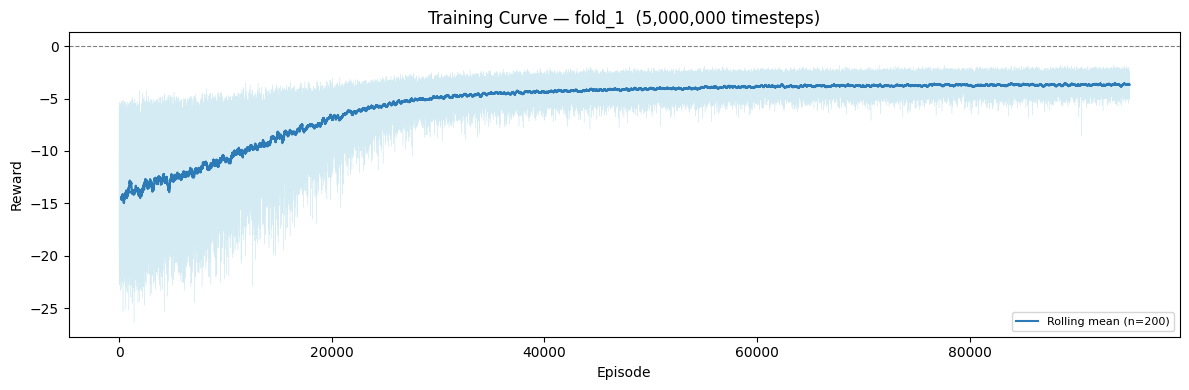

  ✅ fold_1 complete. Best model loaded.

  TRAINING — fold_2  (train → 2020-12-31, val → 2021-12-31)
  Train days: 1335  |  Timesteps: 6,112,637
  Parameters : 556,143
  n_envs     : 4  (DummyVecEnv)
  obs_dim    : 543


C:\Users\youssef\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\stable_baselines3\common\callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_monitor.VecMonitor object at 0x000001DD52507B10> != <stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv object at 0x000001DD5258AB10>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


Eval num_timesteps=20000, episode_reward=-3.00 +/- 0.00
Episode length: 36.00 +/- 0.00
New best mean reward!


Eval num_timesteps=40000, episode_reward=-3.00 +/- 0.00
Episode length: 36.00 +/- 0.00


Eval num_timesteps=60000, episode_reward=-2.94 +/- 0.00
Episode length: 36.00 +/- 0.00
New best mean reward!


...

Eval num_timesteps=4180000, episode_reward=-1.88 +/- 0.00
Episode length: 36.00 +/- 0.00


Eval num_timesteps=4200000, episode_reward=-1.91 +/- 0.00
Episode length: 36.00 +/- 0.00


Eval num_timesteps=4220000, episode_reward=-1.86 +/- 0.00
Episode length: 36.00 +/- 0.00


Eval num_timesteps=4240000, episode_reward=-1.87 +/- 0.00
Episode length: 36.00 +/- 0.00


Eval num_timesteps=4260000, episode_reward=-1.87 +/- 0.00
Episode length: 36.00 +/- 0.00
Stopping training because there was no new best model in the last 51 evaluations


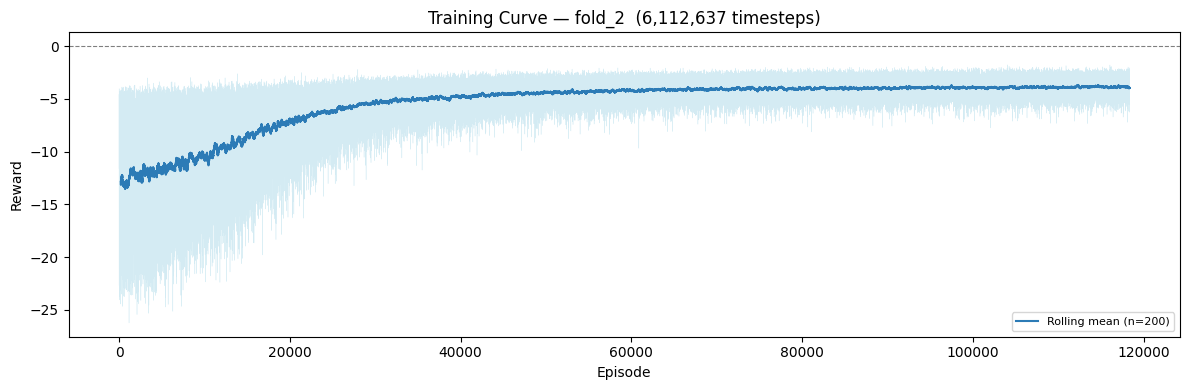

  ✅ fold_2 complete. Best model loaded.

  TRAINING — fold_3  (train → 2021-12-31, val → 2022-12-31)
  Train days: 1579  |  Timesteps: 7,229,853
  Parameters : 556,143
  n_envs     : 4  (DummyVecEnv)
  obs_dim    : 543


C:\Users\youssef\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\stable_baselines3\common\callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_monitor.VecMonitor object at 0x000001DD583A20D0> != <stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv object at 0x000001DD525A2AD0>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


Eval num_timesteps=20000, episode_reward=-4.71 +/- 0.00
Episode length: 36.00 +/- 0.00
New best mean reward!


Eval num_timesteps=40000, episode_reward=-4.67 +/- 0.00
Episode length: 36.00 +/- 0.00
New best mean reward!


Eval num_timesteps=60000, episode_reward=-4.65 +/- 0.00
Episode length: 36.00 +/- 0.00
New best mean reward!


...

Eval num_timesteps=3440000, episode_reward=-1.82 +/- 0.00
Episode length: 36.00 +/- 0.00


Eval num_timesteps=3460000, episode_reward=-1.83 +/- 0.00
Episode length: 36.00 +/- 0.00


Eval num_timesteps=3480000, episode_reward=-1.79 +/- 0.00
Episode length: 36.00 +/- 0.00


Eval num_timesteps=3500000, episode_reward=-1.80 +/- 0.00
Episode length: 36.00 +/- 0.00


Eval num_timesteps=3520000, episode_reward=-1.76 +/- 0.00
Episode length: 36.00 +/- 0.00
Stopping training because there was no new best model in the last 51 evaluations


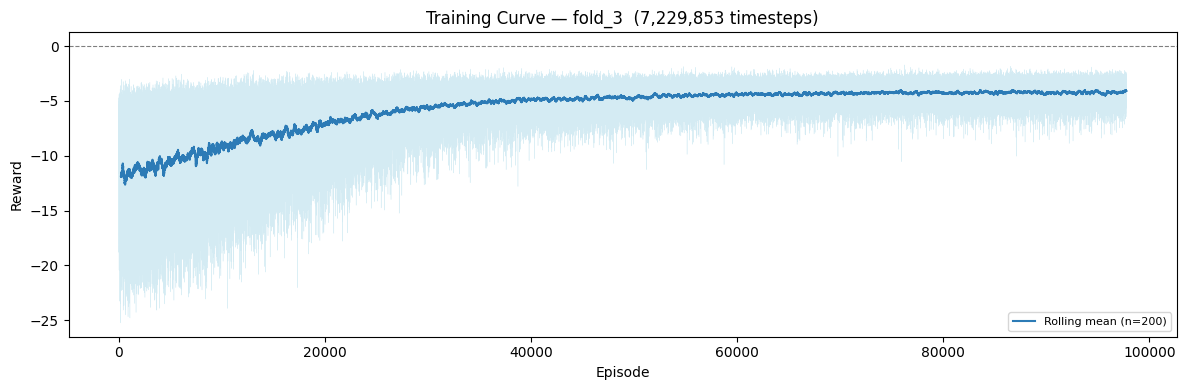

  ✅ fold_3 complete. Best model loaded.

  TRAINING — fold_4  (train → 2022-12-31, val → 2023-12-31)
  Train days: 1823  |  Timesteps: 8,347,069


  Parameters : 556,143
  n_envs     : 4  (DummyVecEnv)
  obs_dim    : 543


C:\Users\youssef\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\stable_baselines3\common\callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_monitor.VecMonitor object at 0x000001DD584B1810> != <stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv object at 0x000001DD52674500>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


Eval num_timesteps=20000, episode_reward=-2.73 +/- 0.00
Episode length: 36.00 +/- 0.00
New best mean reward!


Eval num_timesteps=40000, episode_reward=-2.66 +/- 0.00
Episode length: 36.00 +/- 0.00
New best mean reward!


...

Eval num_timesteps=1560000, episode_reward=-1.80 +/- 0.00
Episode length: 36.00 +/- 0.00


Eval num_timesteps=1580000, episode_reward=-1.76 +/- 0.00
Episode length: 36.00 +/- 0.00


Eval num_timesteps=1600000, episode_reward=-1.75 +/- 0.00
Episode length: 36.00 +/- 0.00


Eval num_timesteps=1620000, episode_reward=-1.76 +/- 0.00
Episode length: 36.00 +/- 0.00


Eval num_timesteps=1640000, episode_reward=-1.72 +/- 0.00
Episode length: 36.00 +/- 0.00
Stopping training because there was no new best model in the last 51 evaluations


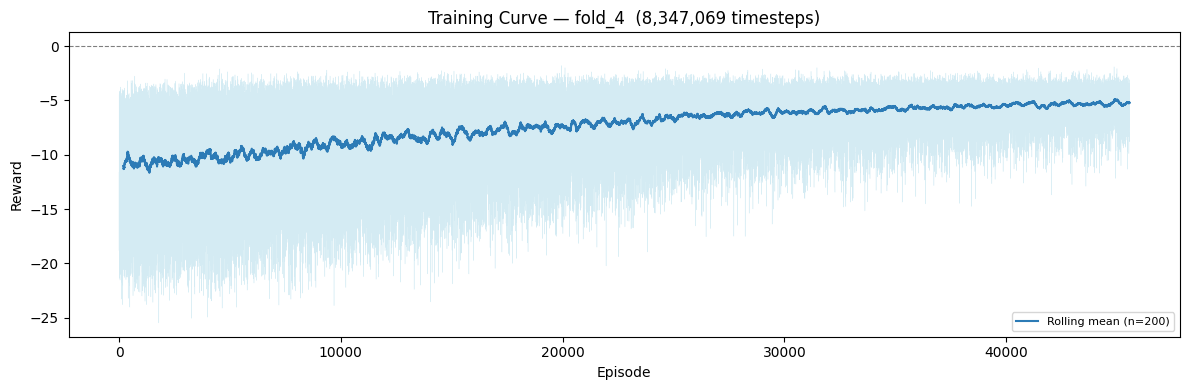

  ✅ fold_4 complete. Best model loaded.


In [24]:
fold_models     = {}
fold_plots_dirs = {}

for fold in WALK_FORWARD_FOLDS:
    fold_name  = fold["name"]
    split      = fold_split_indices[fold_name]

    n_train_days   = len(split["train"])
    fold_timesteps = int(BASE_TIMESTEPS * n_train_days / _fold1_train_days)

    fold_models_dir  = BASE_DIR / "models"  / RISK_PROFILE / VERSION / fold_name
    fold_logs_dir    = BASE_DIR / "logs"    / RISK_PROFILE / VERSION / fold_name
    fold_plots_dir   = BASE_DIR / "outputs" / RISK_PROFILE / VERSION / fold_name / "plots"
    fold_results_dir = BASE_DIR / "outputs" / RISK_PROFILE / VERSION / fold_name / "results"
    for d in [fold_models_dir, fold_logs_dir, fold_plots_dir, fold_results_dir]:
        d.mkdir(parents=True, exist_ok=True)

    fold_plots_dirs[fold_name] = fold_plots_dir
    model_save_path = fold_models_dir / "best_model"

    print(f"\n{'='*62}")
    print(f"  TRAINING — {fold_name}  "
          f"(train → {fold['train_end']}, val → {fold['val_end']})")
    print(f"  Train days: {n_train_days}  |  Timesteps: {fold_timesteps:,}")
    print(f"{'='*62}")

    def make_env_fn(split_indices=split):
        def _init():
            return PortfolioEnv(
                feature_tensor      = feature_tensor,
                returns_tensor      = returns_tensor,
                mask_tensor         = mask_tensor,
                market_signal       = market_signal,
                profile_mask_tensor = profile_mask_tensor,
                universe_indices    = universe_indices,
                split_indices       = split_indices,
                risk_profile        = RISK_PROFILE,
                feature_names       = feature_names,
                mode                = "train",
                episode_length      = EPISODE_LENGTH,
                rebalance_days      = REBALANCE_DAYS,
                silent              = True,
            )
        return _init

    train_vec = DummyVecEnv([make_env_fn(split) for _ in range(N_ENVS)])
    train_vec = VecMonitor(train_vec,
                           filename=str(fold_logs_dir / "monitor_train"))

    val_env_single = PortfolioEnv(
        feature_tensor      = feature_tensor,
        returns_tensor      = returns_tensor,
        mask_tensor         = mask_tensor,
        market_signal       = market_signal,
        profile_mask_tensor = profile_mask_tensor,
        universe_indices    = universe_indices,
        split_indices       = split,
        risk_profile        = RISK_PROFILE,
        feature_names       = feature_names,
        mode                = "val",
        episode_length      = EPISODE_LENGTH,
        rebalance_days      = REBALANCE_DAYS,
        silent              = True,
    )
    val_env_monitored = Monitor(val_env_single,
                                filename=str(fold_logs_dir / "monitor_val"))

    model = PPO(
        env             = train_vec,
        seed            = 42,
        tensorboard_log = str(fold_logs_dir / "tensorboard"),
        **PPO_PARAMS,
    )

    total_params = sum(p.numel() for p in model.policy.parameters())
    print(f"  Parameters : {total_params:,}")
    print(f"  n_envs     : {N_ENVS}  (DummyVecEnv)")
    print(f"  obs_dim    : {model.observation_space.shape[0]}")

    stop_callback = StopTrainingOnNoModelImprovement(
        max_no_improvement_evals = 50,
        min_evals                = 60,
        verbose                  = 1,
    )
    eval_callback = EvalWithStopCallback(
        stop_callback        = stop_callback,
        eval_env             = val_env_monitored,
        best_model_save_path = str(model_save_path),
        log_path             = str(fold_logs_dir / "eval"),
        eval_freq            = max(20_000 // N_ENVS, 1),
        n_eval_episodes      = 1,
        deterministic        = True,
        render               = False,
        verbose              = 1,
    )
    reward_logger = RewardLoggerCallback(
        log_path = str(fold_logs_dir / "rl_training_history.csv"),
        verbose  = 1,
    )
    metrics_callback = TrainingMetricsCallback(
        print_every_n_updates = 20,
        verbose               = 1,
    )

    model.learn(
        total_timesteps     = fold_timesteps,
        callback            = [eval_callback, reward_logger, metrics_callback],
        progress_bar        = False,
        reset_num_timesteps = True,
    )

    history_path = fold_logs_dir / "rl_training_history.csv"
    if history_path.exists():
        history_df = pd.read_csv(str(history_path))
        window     = 200
        history_df["rolling_mean"] = history_df["episode_reward"].rolling(window).mean()

        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(history_df["episode"], history_df["episode_reward"],
                color="#abd9e9", linewidth=0.3, alpha=0.5)
        ax.plot(history_df["episode"], history_df["rolling_mean"],
                color="#2c7bb6", linewidth=1.5, label=f"Rolling mean (n={window})")
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
        ax.set_xlabel("Episode")
        ax.set_ylabel("Reward")
        ax.set_title(f"Training Curve — {fold_name}  ({fold_timesteps:,} timesteps)")
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(fold_plots_dir / "training_curve.png", dpi=120, bbox_inches="tight")
        plt.show()

        sys.__stdout__.write(
            f"  Episodes: {len(history_df):,} | "
            f"First 500 mean: {history_df['episode_reward'][:500].mean():.3f} | "
            f"Last 500 mean: {history_df['episode_reward'][-500:].mean():.3f}\n"
        )

    best_model = PPO.load(
        str(model_save_path / "best_model"),
        env=val_env_monitored,
    )
    fold_models[fold_name] = best_model
    print(f"  ✅ {fold_name} complete. Best model loaded.")

## 12. Multi-Episode Evaluation Across All Folds

In [25]:
_template_env = PortfolioEnv(
    feature_tensor      = feature_tensor,
    returns_tensor      = returns_tensor,
    mask_tensor         = mask_tensor,
    market_signal       = market_signal,
    profile_mask_tensor = profile_mask_tensor,
    universe_indices    = universe_indices,
    split_indices       = fold_split_indices["fold_1"],
    risk_profile        = RISK_PROFILE,
    feature_names       = feature_names,
    mode                = "test",
    episode_length      = EPISODE_LENGTH,
    rebalance_days      = REBALANCE_DAYS,
    silent              = True,
)


  EVALUATION — fold_1  (test → 2021-12-31)

[VAL]


  RL  : 1800 returns from 50 episodes
  EQW : 1800 returns

-- RL Agent — val [fold_1] --
  N returns             : 1800
  Annualized return     :    46.22%
  Risk-free (CONIA)     :    21.00%
  Annualized vol        :    19.85%
  Sharpe ratio          :    1.271
  Sortino ratio         :    2.827
  Max drawdown          :    23.82%
  Calmar ratio          :    1.940
  CVaR (95%, per-period):   -6.39%
  Win rate vs RFR       :    62.4%  (1124/1800 periods)

-- Equal Weight — val [fold_1] --
  N returns             : 1800
  Annualized return     :    19.83%
  Risk-free (CONIA)     :    21.00%
  Annualized vol        :    21.78%
  Sharpe ratio          :   -0.054
  Sortino ratio         :   -0.086
  Max drawdown          :    35.76%
  Calmar ratio          :    0.555
  CVaR (95%, per-period):  -11.19%
  Win rate vs RFR       :    49.9%  (899/1800 periods)



  Bootstrap CIs (95%, block=3, n=2000) — RL val [fold_1]
    Ann. return          : [+42.95%, +49.52%]
    Sharpe               : [+1.132,  +1.413]
    CVaR 95% (per-period): [-7.28%, -5.47%]



  Bootstrap CIs (95%, block=3, n=2000) — EQW val [fold_1]
    Ann. return          : [+16.36%, +23.71%]
    Sharpe               : [-0.227,  +0.128]
    CVaR 95% (per-period): [-12.60%, -9.91%]

  Statistical tests (val fold_1):
    H0: RL excess return == equal-weight excess return
    t-test  : t=+34.789  p=0.0000  ✓ significant at 5%  [outperforms EQW]
    Wilcoxon: W=183743.0  p=0.0000  ✓ significant at 5%

[TEST]


  RL  : 1800 returns from 50 episodes
  EQW : 1800 returns

-- RL Agent — test [fold_1] --
  N returns             : 1800
  Annualized return     :    47.61%
  Risk-free (CONIA)     :    21.00%
  Annualized vol        :    24.11%
  Sharpe ratio          :    1.104
  Sortino ratio         :    2.110
  Max drawdown          :    23.88%
  Calmar ratio          :    1.993
  CVaR (95%, per-period):  -10.21%
  Win rate vs RFR       :    61.7%  (1111/1800 periods)

-- Equal Weight — test [fold_1] --
  N returns             : 1800
  Annualized return     :    30.67%
  Risk-free (CONIA)     :    21.00%
  Annualized vol        :    24.16%
  Sharpe ratio          :    0.400
  Sortino ratio         :    0.688
  Max drawdown          :    26.57%
  Calmar ratio          :    1.154
  CVaR (95%, per-period):  -12.03%
  Win rate vs RFR       :    54.8%  (987/1800 periods)



  Bootstrap CIs (95%, block=3, n=2000) — RL test [fold_1]
    Ann. return          : [+43.67%, +51.65%]
    Sharpe               : [+0.953,  +1.266]
    CVaR 95% (per-period): [-11.29%, -8.99%]



  Bootstrap CIs (95%, block=3, n=2000) — EQW test [fold_1]
    Ann. return          : [+26.70%, +34.96%]
    Sharpe               : [+0.233,  +0.565]
    CVaR 95% (per-period): [-12.74%, -11.13%]

  Statistical tests (test fold_1):
    H0: RL excess return == equal-weight excess return
    t-test  : t=+20.317  p=0.0000  ✓ significant at 5%  [outperforms EQW]
    Wilcoxon: W=397319.0  p=0.0000  ✓ significant at 5%

[ACTIVE METRICS — TEST]



── Active Metrics [fold_1 test] ──
  Information Ratio    :    1.659
  Win Rate vs EQW      :    69.7%  (1254/1800 periods)
  Avg Turnover/step    :   105.8%
  Avg Active Stocks    :     9.9


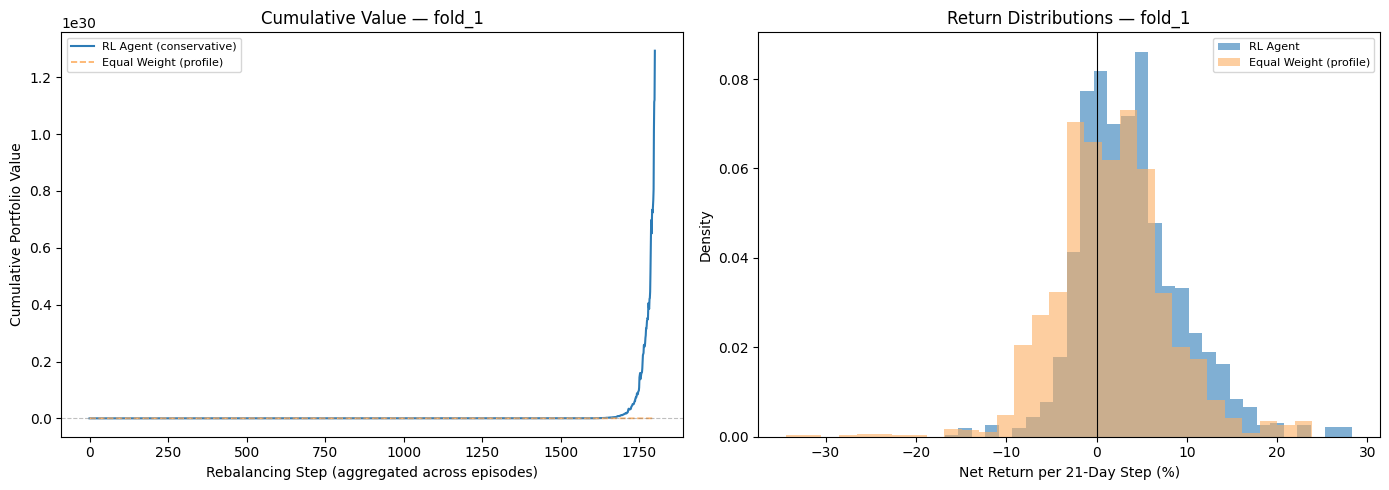

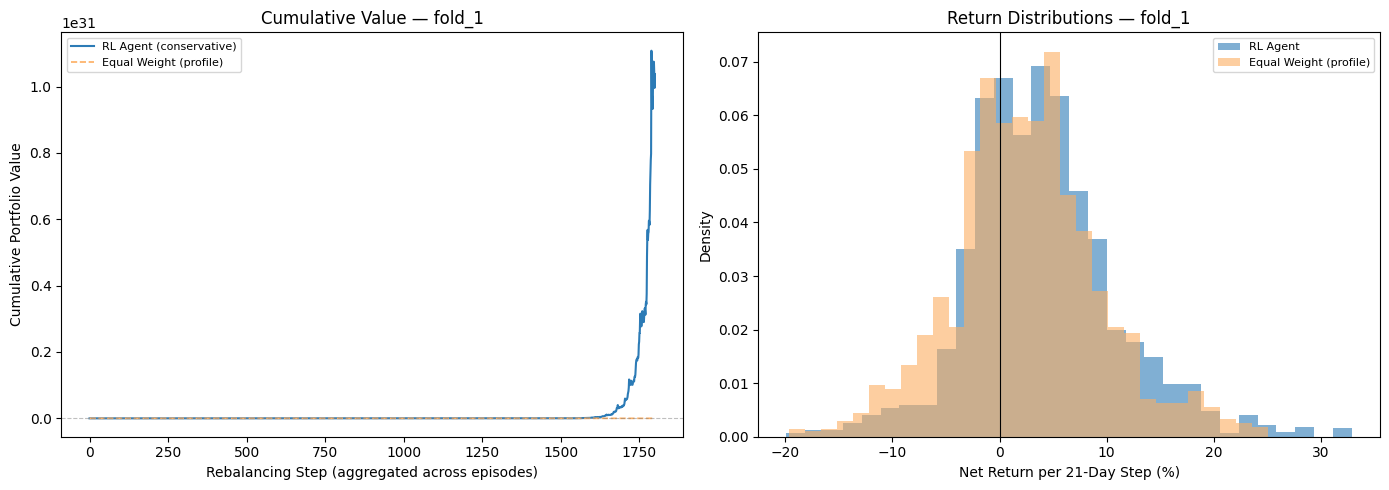


  EVALUATION — fold_2  (test → 2022-12-31)

[VAL]


  RL  : 1800 returns from 50 episodes
  EQW : 1800 returns

-- RL Agent — val [fold_2] --
  N returns             : 1800
  Annualized return     :    61.52%
  Risk-free (CONIA)     :    21.00%
  Annualized vol        :    26.38%
  Sharpe ratio          :    1.536
  Sortino ratio         :    3.447
  Max drawdown          :    25.64%
  Calmar ratio          :    2.399
  CVaR (95%, per-period):   -8.53%
  Win rate vs RFR       :    67.1%  (1207/1800 periods)

-- Equal Weight — val [fold_2] --
  N returns             : 1800
  Annualized return     :    30.67%
  Risk-free (CONIA)     :    21.00%
  Annualized vol        :    24.16%
  Sharpe ratio          :    0.400
  Sortino ratio         :    0.688
  Max drawdown          :    26.57%
  Calmar ratio          :    1.154
  CVaR (95%, per-period):  -12.03%
  Win rate vs RFR       :    54.8%  (987/1800 periods)



  Bootstrap CIs (95%, block=3, n=2000) — RL val [fold_2]
    Ann. return          : [+57.07%, +65.93%]
    Sharpe               : [+1.387,  +1.685]
    CVaR 95% (per-period): [-9.61%, -7.35%]



  Bootstrap CIs (95%, block=3, n=2000) — EQW val [fold_2]
    Ann. return          : [+26.62%, +34.59%]
    Sharpe               : [+0.233,  +0.567]
    CVaR 95% (per-period): [-12.78%, -11.05%]

  Statistical tests (val fold_2):
    H0: RL excess return == equal-weight excess return
    t-test  : t=+35.051  p=0.0000  ✓ significant at 5%  [outperforms EQW]
    Wilcoxon: W=175419.0  p=0.0000  ✓ significant at 5%

[TEST]


  RL  : 1800 returns from 50 episodes
  EQW : 1800 returns

-- RL Agent — test [fold_2] --
  N returns             : 1800
  Annualized return     :    52.74%
  Risk-free (CONIA)     :    21.00%
  Annualized vol        :    27.30%
  Sharpe ratio          :    1.163
  Sortino ratio         :    2.846
  Max drawdown          :    25.64%
  Calmar ratio          :    2.057
  CVaR (95%, per-period):   -8.92%
  Win rate vs RFR       :    60.1%  (1082/1800 periods)

-- Equal Weight — test [fold_2] --
  N returns             : 1800
  Annualized return     :    31.82%
  Risk-free (CONIA)     :    21.00%
  Annualized vol        :    23.42%
  Sharpe ratio          :    0.462
  Sortino ratio         :    0.771
  Max drawdown          :    26.94%
  Calmar ratio          :    1.181
  CVaR (95%, per-period):  -12.28%
  Win rate vs RFR       :    54.2%  (976/1800 periods)



  Bootstrap CIs (95%, block=3, n=2000) — RL test [fold_2]
    Ann. return          : [+48.08%, +57.42%]
    Sharpe               : [+1.010,  +1.312]
    CVaR 95% (per-period): [-9.81%, -7.93%]



  Bootstrap CIs (95%, block=3, n=2000) — EQW test [fold_2]
    Ann. return          : [+27.91%, +35.82%]
    Sharpe               : [+0.299,  +0.626]
    CVaR 95% (per-period): [-13.03%, -11.25%]

  Statistical tests (test fold_2):
    H0: RL excess return == equal-weight excess return
    t-test  : t=+22.896  p=0.0000  ✓ significant at 5%  [outperforms EQW]
    Wilcoxon: W=351260.0  p=0.0000  ✓ significant at 5%

[ACTIVE METRICS — TEST]



── Active Metrics [fold_2 test] ──
  Information Ratio    :    1.870
  Win Rate vs EQW      :    69.7%  (1255/1800 periods)
  Avg Turnover/step    :    96.2%
  Avg Active Stocks    :    10.0


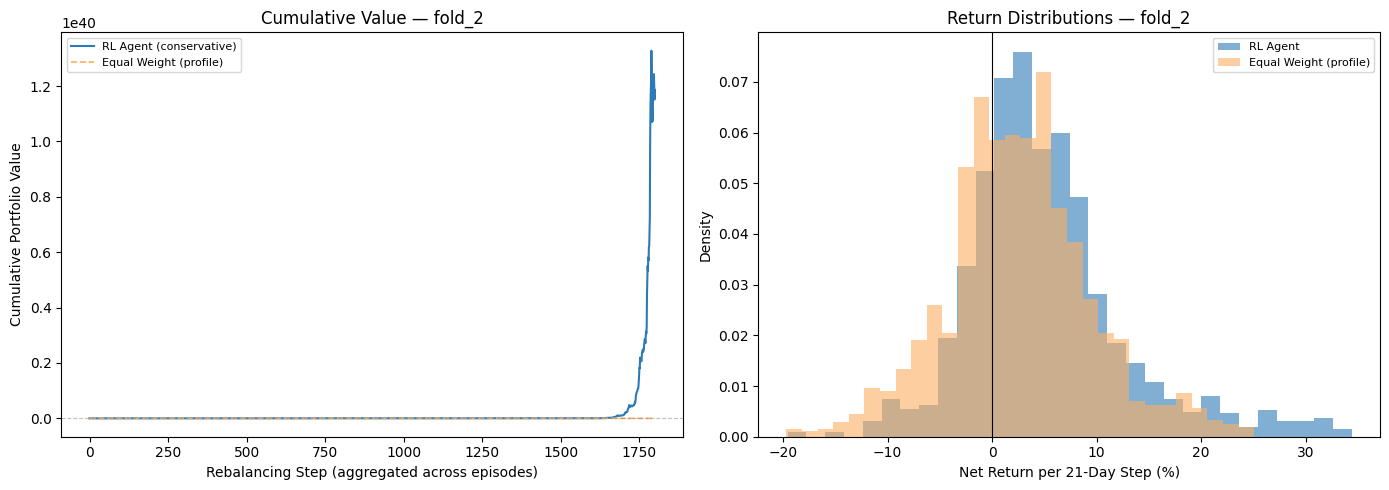

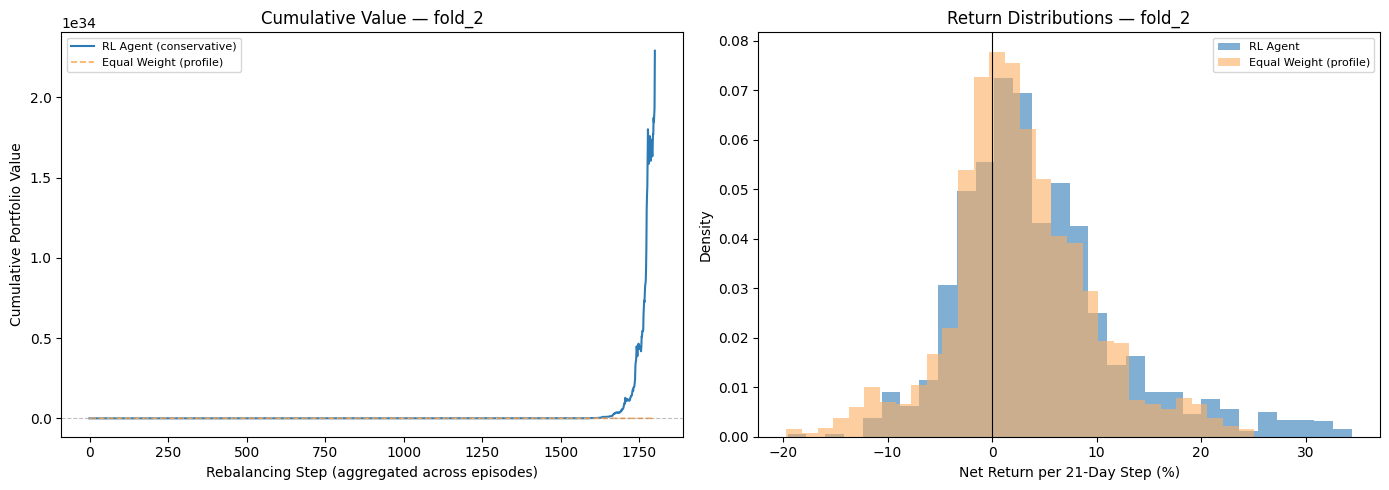


  EVALUATION — fold_3  (test → 2023-12-31)

[VAL]


  RL  : 1800 returns from 50 episodes
  EQW : 1800 returns

-- RL Agent — val [fold_3] --
  N returns             : 1800
  Annualized return     :    65.96%
  Risk-free (CONIA)     :    21.00%
  Annualized vol        :    26.07%
  Sharpe ratio          :    1.724
  Sortino ratio         :    5.103
  Max drawdown          :    13.77%
  Calmar ratio          :    4.789
  CVaR (95%, per-period):   -6.35%
  Win rate vs RFR       :    64.9%  (1169/1800 periods)

-- Equal Weight — val [fold_3] --
  N returns             : 1800
  Annualized return     :    31.82%
  Risk-free (CONIA)     :    21.00%
  Annualized vol        :    23.42%
  Sharpe ratio          :    0.462
  Sortino ratio         :    0.771
  Max drawdown          :    26.94%
  Calmar ratio          :    1.181
  CVaR (95%, per-period):  -12.28%
  Win rate vs RFR       :    54.2%  (976/1800 periods)



  Bootstrap CIs (95%, block=3, n=2000) — RL val [fold_3]
    Ann. return          : [+61.38%, +70.67%]
    Sharpe               : [+1.576,  +1.886]
    CVaR 95% (per-period): [-7.01%, -5.75%]



  Bootstrap CIs (95%, block=3, n=2000) — EQW val [fold_3]
    Ann. return          : [+27.93%, +35.69%]
    Sharpe               : [+0.288,  +0.619]
    CVaR 95% (per-period): [-12.99%, -11.22%]

  Statistical tests (val fold_3):
    H0: RL excess return == equal-weight excess return
    t-test  : t=+36.590  p=0.0000  ✓ significant at 5%  [outperforms EQW]
    Wilcoxon: W=170793.0  p=0.0000  ✓ significant at 5%

[TEST]


  RL  : 1800 returns from 50 episodes
  EQW : 1800 returns

-- RL Agent — test [fold_3] --
  N returns             : 1800
  Annualized return     :    56.61%
  Risk-free (CONIA)     :    21.00%
  Annualized vol        :    23.86%
  Sharpe ratio          :    1.492
  Sortino ratio         :    4.321
  Max drawdown          :    13.27%
  Calmar ratio          :    4.266
  CVaR (95%, per-period):   -6.03%
  Win rate vs RFR       :    62.1%  (1118/1800 periods)

-- Equal Weight — test [fold_3] --
  N returns             : 1800
  Annualized return     :    32.76%
  Risk-free (CONIA)     :    21.00%
  Annualized vol        :    20.68%
  Sharpe ratio          :    0.569
  Sortino ratio         :    0.877
  Max drawdown          :    23.34%
  Calmar ratio          :    1.404
  CVaR (95%, per-period):  -11.45%
  Win rate vs RFR       :    55.9%  (1006/1800 periods)



  Bootstrap CIs (95%, block=3, n=2000) — RL test [fold_3]
    Ann. return          : [+52.25%, +61.17%]
    Sharpe               : [+1.346,  +1.642]
    CVaR 95% (per-period): [-6.70%, -5.41%]



  Bootstrap CIs (95%, block=3, n=2000) — EQW test [fold_3]
    Ann. return          : [+29.39%, +35.94%]
    Sharpe               : [+0.405,  +0.719]
    CVaR 95% (per-period): [-12.62%, -9.95%]

  Statistical tests (test fold_3):
    H0: RL excess return == equal-weight excess return
    t-test  : t=+22.292  p=0.0000  ✓ significant at 5%  [outperforms EQW]
    Wilcoxon: W=363612.0  p=0.0000  ✓ significant at 5%

[ACTIVE METRICS — TEST]



── Active Metrics [fold_3 test] ──
  Information Ratio    :    1.821
  Win Rate vs EQW      :    68.6%  (1235/1800 periods)
  Avg Turnover/step    :    95.5%
  Avg Active Stocks    :     9.9


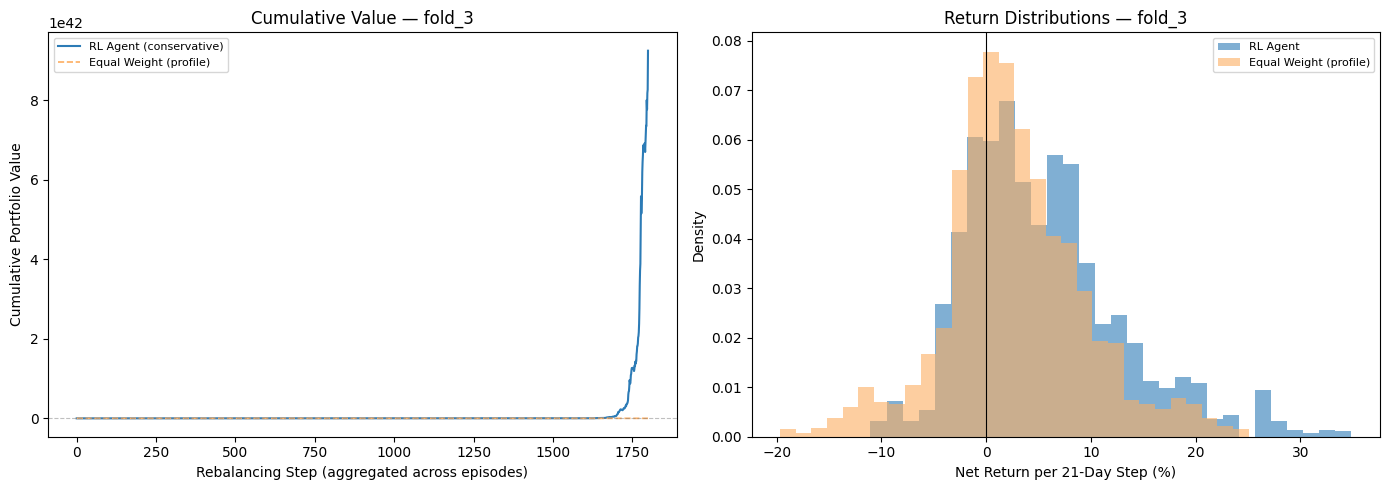

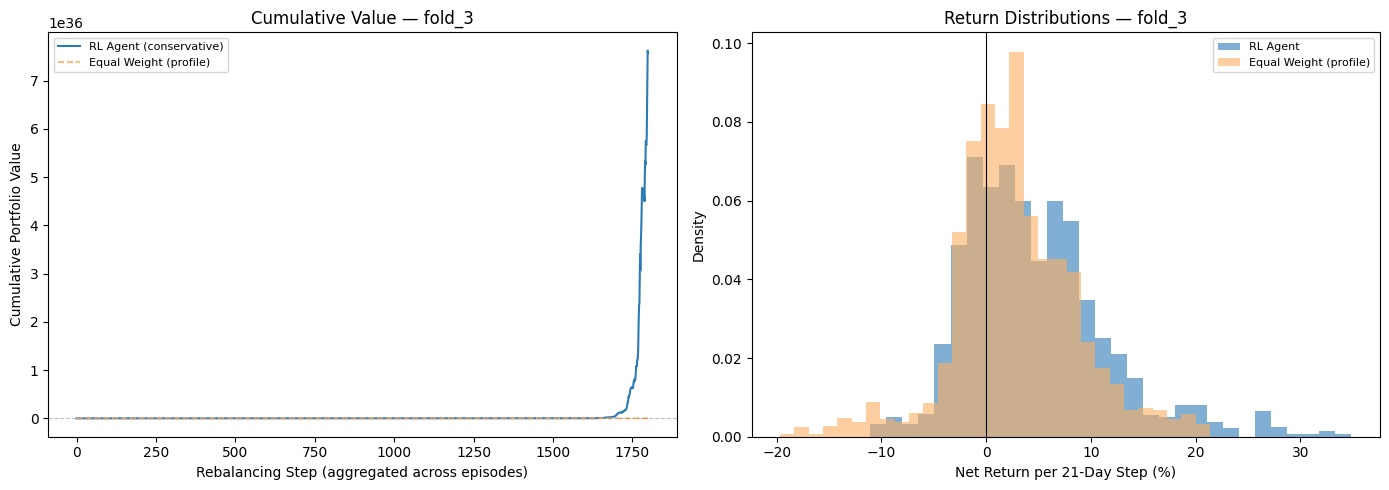


  EVALUATION — fold_4  (test → 2026-06-04)

[VAL]


  RL  : 1800 returns from 50 episodes
  EQW : 1800 returns

-- RL Agent — val [fold_4] --
  N returns             : 1800
  Annualized return     :    46.60%
  Risk-free (CONIA)     :    21.00%
  Annualized vol        :    19.47%
  Sharpe ratio          :    1.315
  Sortino ratio         :    2.833
  Max drawdown          :    13.17%
  Calmar ratio          :    3.538
  CVaR (95%, per-period):   -6.64%
  Win rate vs RFR       :    62.1%  (1117/1800 periods)

-- Equal Weight — val [fold_4] --
  N returns             : 1800
  Annualized return     :    32.76%
  Risk-free (CONIA)     :    21.00%
  Annualized vol        :    20.68%
  Sharpe ratio          :    0.569
  Sortino ratio         :    0.877
  Max drawdown          :    23.34%
  Calmar ratio          :    1.404
  CVaR (95%, per-period):  -11.45%
  Win rate vs RFR       :    55.9%  (1006/1800 periods)



  Bootstrap CIs (95%, block=3, n=2000) — RL val [fold_4]
    Ann. return          : [+43.59%, +49.43%]
    Sharpe               : [+1.181,  +1.455]
    CVaR 95% (per-period): [-7.43%, -5.82%]



  Bootstrap CIs (95%, block=3, n=2000) — EQW val [fold_4]
    Ann. return          : [+29.59%, +35.96%]
    Sharpe               : [+0.405,  +0.737]
    CVaR 95% (per-period): [-12.65%, -9.97%]

  Statistical tests (val fold_4):
    H0: RL excess return == equal-weight excess return
    t-test  : t=+23.041  p=0.0000  ✓ significant at 5%  [outperforms EQW]
    Wilcoxon: W=336386.0  p=0.0000  ✓ significant at 5%

[TEST]


  RL  : 800 returns from 50 episodes
  EQW : 800 returns

-- RL Agent — test [fold_4] --
  N returns             : 800
  Annualized return     :    32.89%
  Risk-free (CONIA)     :    21.00%
  Annualized vol        :    15.23%
  Sharpe ratio          :    0.781
  Sortino ratio         :    1.735
  Max drawdown          :    11.74%
  Calmar ratio          :    2.803
  CVaR (95%, per-period):   -4.95%
  Win rate vs RFR       :    55.1%  (441/800 periods)

-- Equal Weight — test [fold_4] --
  N returns             : 800
  Annualized return     :    21.41%
  Risk-free (CONIA)     :    21.00%
  Annualized vol        :    16.42%
  Sharpe ratio          :    0.025
  Sortino ratio         :    0.041
  Max drawdown          :    21.65%
  Calmar ratio          :    0.989
  CVaR (95%, per-period):   -8.32%
  Win rate vs RFR       :    50.0%  (400/800 periods)



  Bootstrap CIs (95%, block=3, n=2000) — RL test [fold_4]
    Ann. return          : [+29.52%, +36.50%]
    Sharpe               : [+0.568,  +0.994]
    CVaR 95% (per-period): [-5.75%, -4.11%]



  Bootstrap CIs (95%, block=3, n=2000) — EQW test [fold_4]
    Ann. return          : [+17.48%, +25.22%]
    Sharpe               : [-0.215,  +0.260]
    CVaR 95% (per-period): [-10.33%, -6.40%]

  Statistical tests (test fold_4):
    H0: RL excess return == equal-weight excess return
    t-test  : t=+15.560  p=0.0000  ✓ significant at 5%  [outperforms EQW]
    Wilcoxon: W=63665.0  p=0.0000  ✓ significant at 5%

[ACTIVE METRICS — TEST]



── Active Metrics [fold_4 test] ──
  Information Ratio    :    1.907
  Win Rate vs EQW      :    73.4%  (587/800 periods)
  Avg Turnover/step    :    67.5%
  Avg Active Stocks    :     9.9


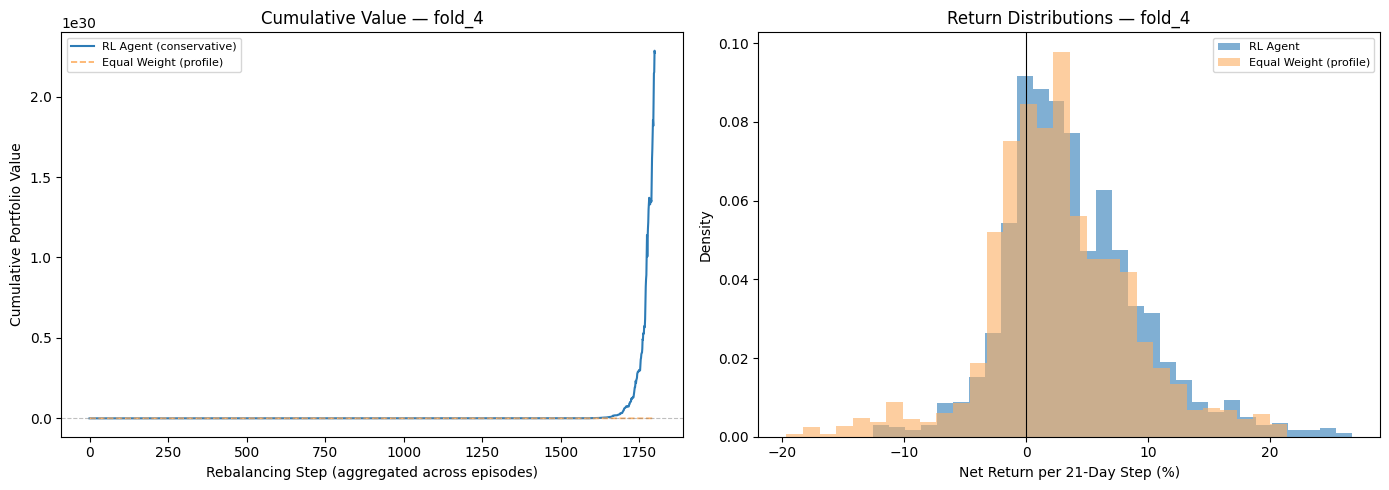

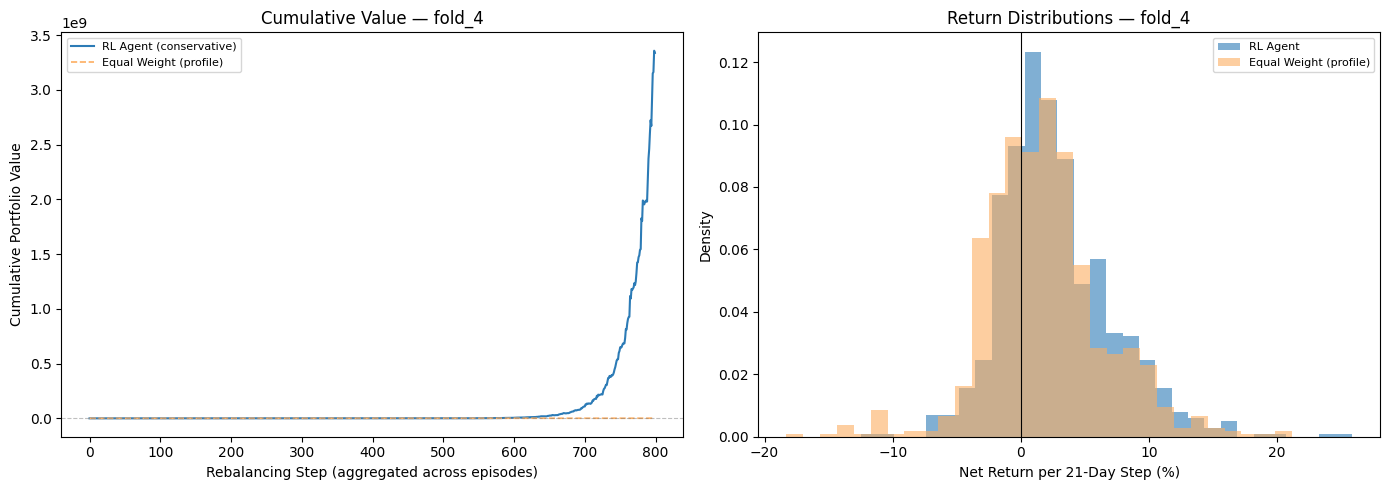


✅ All fold evaluations complete.


In [26]:
all_fold_results = {}

for fold in WALK_FORWARD_FOLDS:
    fold_name = fold["name"]
    split     = fold_split_indices[fold_name]
    model     = fold_models[fold_name]
    plots_dir = fold_plots_dirs[fold_name]

    print(f"\n{'='*60}")
    print(f"  EVALUATION — {fold_name}  (test → {fold['test_end']})")
    print(f"{'='*60}")

    print(f"\n[VAL]")
    rl_val_returns, rl_val_episodes = multi_episode_evaluate(
        model, _template_env, split, "val", EPISODE_LENGTH
    )
    eq_val_returns = multi_episode_equal_weight(
        _template_env, split, "val", EPISODE_LENGTH
    )
    print(f"  RL  : {len(rl_val_returns)} returns from {len(rl_val_episodes)} episodes")
    print(f"  EQW : {len(eq_val_returns)} returns")

    rl_val_metrics = compute_metrics(rl_val_returns,  f"RL Agent — val [{fold_name}]")
    eq_val_metrics = compute_metrics(eq_val_returns,   f"Equal Weight — val [{fold_name}]")
    rl_val_ci      = compute_bootstrap_cis(rl_val_returns,  f"RL val [{fold_name}]")
    eq_val_ci      = compute_bootstrap_cis(eq_val_returns,   f"EQW val [{fold_name}]")
    val_sig        = significance_test(
        rl_val_returns[:min(len(rl_val_returns), len(eq_val_returns))],
        eq_val_returns[:min(len(rl_val_returns), len(eq_val_returns))],
        label=f"val {fold_name}"
    )

    print(f"\n[TEST]")
    test_episode_length = 16 if fold_name == "fold_4" else EPISODE_LENGTH
    rl_test_returns, rl_test_episodes = multi_episode_evaluate(
        model, _template_env, split, "test", test_episode_length
    )
    eq_test_returns = multi_episode_equal_weight(
        _template_env, split, "test", test_episode_length
    )
    print(f"  RL  : {len(rl_test_returns)} returns from {len(rl_test_episodes)} episodes")
    print(f"  EQW : {len(eq_test_returns)} returns")

    rl_test_metrics = compute_metrics(rl_test_returns,  f"RL Agent — test [{fold_name}]")
    eq_test_metrics = compute_metrics(eq_test_returns,   f"Equal Weight — test [{fold_name}]")
    rl_test_ci      = compute_bootstrap_cis(rl_test_returns,  f"RL test [{fold_name}]")
    eq_test_ci      = compute_bootstrap_cis(eq_test_returns,   f"EQW test [{fold_name}]")
    test_sig        = significance_test(
        rl_test_returns[:min(len(rl_test_returns), len(eq_test_returns))],
        eq_test_returns[:min(len(rl_test_returns), len(eq_test_returns))],
        label=f"test {fold_name}"
    )

    print(f"\n[ACTIVE METRICS — TEST]")
    active_metrics_test = compute_active_metrics(
        rl_returns   = rl_test_returns,
        eq_returns   = eq_test_returns,
        model        = model,
        env_template = _template_env,
        split_indices = split,
        mode         = "test",
        episode_length = test_episode_length,
        fold_name    = fold_name,
    )

    plot_fold_results(rl_val_returns,  eq_val_returns,  fold_name, "val",  plots_dir)
    plot_fold_results(rl_test_returns, eq_test_returns, fold_name, "test", plots_dir)

    fold_result = {
        "fold":              fold_name,
        "train_end":         fold["train_end"],
        "val_end":           fold["val_end"],
        "test_end":          fold["test_end"],
        "rl_val":            rl_val_metrics,
        "eq_val":            eq_val_metrics,
        "rl_val_ci":         rl_val_ci,
        "rl_test":           rl_test_metrics,
        "eq_test":           eq_test_metrics,
        "rl_test_ci":        rl_test_ci,
        "val_significance":  val_sig,
        "test_significance": test_sig,
        "active_metrics": active_metrics_test,
    }
    all_fold_results[fold_name] = fold_result

    results_dir = BASE_DIR / "outputs" / RISK_PROFILE / VERSION / fold_name / "results"
    json.dump(fold_result, open(results_dir / "metrics.json", "w"),
              indent=2, default=str)

print(f"\n✅ All fold evaluations complete.")

## 13. Aggregate Results Across Folds

In [27]:
print(f"\n{'='*65}")
print(f"  CROSS-FOLD AGGREGATE RESULTS  ({len(WALK_FORWARD_FOLDS)} folds)")
print(f"{'='*65}")

metrics_keys = ["ann_return", "ann_vol", "sharpe", "sortino", "max_dd", "calmar", "cvar_95"]

rl_test_rows = []
eq_test_rows = []

for fold_name, result in all_fold_results.items():
    rl_row = {"fold": fold_name, "test_end": result["test_end"]}
    eq_row = {"fold": fold_name, "test_end": result["test_end"]}
    for k in metrics_keys:
        rl_row[k] = result["rl_test"].get(k, np.nan)
        eq_row[k] = result["eq_test"].get(k, np.nan)
    rl_test_rows.append(rl_row)
    eq_test_rows.append(eq_row)

rl_df = pd.DataFrame(rl_test_rows).set_index("fold")
eq_df = pd.DataFrame(eq_test_rows).set_index("fold")

print(f"\n── RL Agent — Test Metrics Per Fold ──")
display_cols = ["test_end", "ann_return", "sharpe", "sortino", "max_dd", "cvar_95"]
rl_display   = rl_df[display_cols].copy()
rl_display["ann_return"] = (rl_display["ann_return"] * 100).round(2)
rl_display["max_dd"]     = (rl_display["max_dd"]     * 100).round(2)
rl_display["cvar_95"]    = (rl_display["cvar_95"]    * 100).round(2)
rl_display["sharpe"]     = rl_display["sharpe"].round(3)
rl_display["sortino"]    = rl_display["sortino"].round(3)
print(rl_display.rename(columns={"cvar_95": "cvar_95(pp%)"}).to_string())

print(f"\n── Equal Weight (profile universe) — Test Metrics Per Fold ──")
eq_display   = eq_df[display_cols].copy()
eq_display["ann_return"] = (eq_display["ann_return"] * 100).round(2)
eq_display["max_dd"]     = (eq_display["max_dd"]     * 100).round(2)
eq_display["cvar_95"]    = (eq_display["cvar_95"]    * 100).round(2)
eq_display["sharpe"]     = eq_display["sharpe"].round(3)
eq_display["sortino"]    = eq_display["sortino"].round(3)
print(eq_display.rename(columns={"cvar_95": "cvar_95(pp%)"}).to_string())

print(f"\n── Cross-Fold Summary (TEST) ──")
print(f"  ann_return, ann_vol, max_dd: annualized (×12 or ×√12)")
print(f"  cvar_95: per-period fraction (NOT annualized) — avg worst 5% of 21d periods")
print(f"{'Metric':<22} {'RL Mean':>10} {'RL Std':>8} │ {'EQ Mean':>10} {'EQ Std':>8}")
print("─" * 67)
for k in metrics_keys:
    rl_vals = rl_df[k].dropna().values
    eq_vals = eq_df[k].dropna().values
    scale   = 100 if k in ["ann_return", "ann_vol", "max_dd", "cvar_95"] else 1
    unit    = "%" if scale == 100 else ""
    rl_mean = np.mean(rl_vals) * scale
    rl_std  = np.std(rl_vals)  * scale
    eq_mean = np.mean(eq_vals) * scale
    eq_std  = np.std(eq_vals)  * scale
    suffix  = " (pp)" if k == "cvar_95" else ""
    print(f"{k+suffix:<22} {rl_mean:>9.2f}{unit} {rl_std:>7.2f}{unit} │ "
          f"{eq_mean:>9.2f}{unit} {eq_std:>7.2f}{unit}")

print(f"\n── Fold-Level Significance Summary ──")
sig_rows = []
for fold_name, result in all_fold_results.items():
    sig = result["test_significance"]
    sig_rows.append({
        "fold":      fold_name,
        "direction": sig.get("direction", "?"),
        "t_pval":    sig.get("t_pval", np.nan),
        "w_pval":    sig.get("w_pval", np.nan),
        "sig_t":     "✓" if sig.get("t_pval", 1) < 0.05 else "✗",
        "sig_w":     "✓" if sig.get("w_pval", 1) < 0.05 else "✗",
    })
sig_df = pd.DataFrame(sig_rows).set_index("fold")
print(sig_df[["direction", "t_pval", "sig_t", "w_pval", "sig_w"]].round(4).to_string())

n_outperforms   = ((sig_df["t_pval"] < 0.05) & (sig_df["direction"] == "outperforms")).sum()
n_underperforms = ((sig_df["t_pval"] < 0.05) & (sig_df["direction"] == "underperforms")).sum()
print(f"\nRL significantly outperforms EQW  : {n_outperforms}/{len(WALK_FORWARD_FOLDS)} folds")
print(f"RL significantly underperforms EQW: {n_underperforms}/{len(WALK_FORWARD_FOLDS)} folds")

# After the existing metrics table, add:
print(f"\n── Active Metrics Summary (TEST) ──")
print(f"{'Metric':<25} {'Mean':>10} {'Std':>8}")
print("─" * 46)

active_keys = ["information_ratio", "win_rate_vs_eq", "avg_turnover", "avg_active_stocks"]
active_labels = {
    "information_ratio":  ("Information Ratio",  1,    ""),
    "win_rate_vs_eq":     ("Win Rate vs EQW",    100,  "%"),
    "avg_turnover":       ("Avg Turnover/step",  100,  "%"),
    "avg_active_stocks":  ("Avg Active Stocks",  1,    ""),
}

for key in active_keys:
    vals = [
        all_fold_results[f]["active_metrics"][key]
        for f in all_fold_results.keys()
        if "active_metrics" in all_fold_results[f]
    ]
    if not vals:
        continue
    label, scale, unit = active_labels[key]
    mean_val = np.mean(vals) * scale
    std_val  = np.std(vals)  * scale
    print(f"{label:<25} {mean_val:>9.2f}{unit} {std_val:>7.2f}{unit}")


  CROSS-FOLD AGGREGATE RESULTS  (4 folds)

── RL Agent — Test Metrics Per Fold ──
          test_end  ann_return  sharpe  sortino  max_dd  cvar_95(pp%)
fold                                                                 
fold_1  2021-12-31       47.61   1.104    2.110   23.88        -10.21
fold_2  2022-12-31       52.74   1.163    2.846   25.64         -8.92
fold_3  2023-12-31       56.61   1.492    4.321   13.27         -6.03
fold_4  2026-06-04       32.89   0.781    1.735   11.74         -4.95

── Equal Weight (profile universe) — Test Metrics Per Fold ──
          test_end  ann_return  sharpe  sortino  max_dd  cvar_95(pp%)
fold                                                                 
fold_1  2021-12-31       30.67   0.400    0.688   26.57        -12.03
fold_2  2022-12-31       31.82   0.462    0.771   26.94        -12.28
fold_3  2023-12-31       32.76   0.569    0.877   23.34        -11.45
fold_4  2026-06-04       21.41   0.025    0.041   21.65         -8.32

── Cross-Fold

## 14. Aggregate Plot

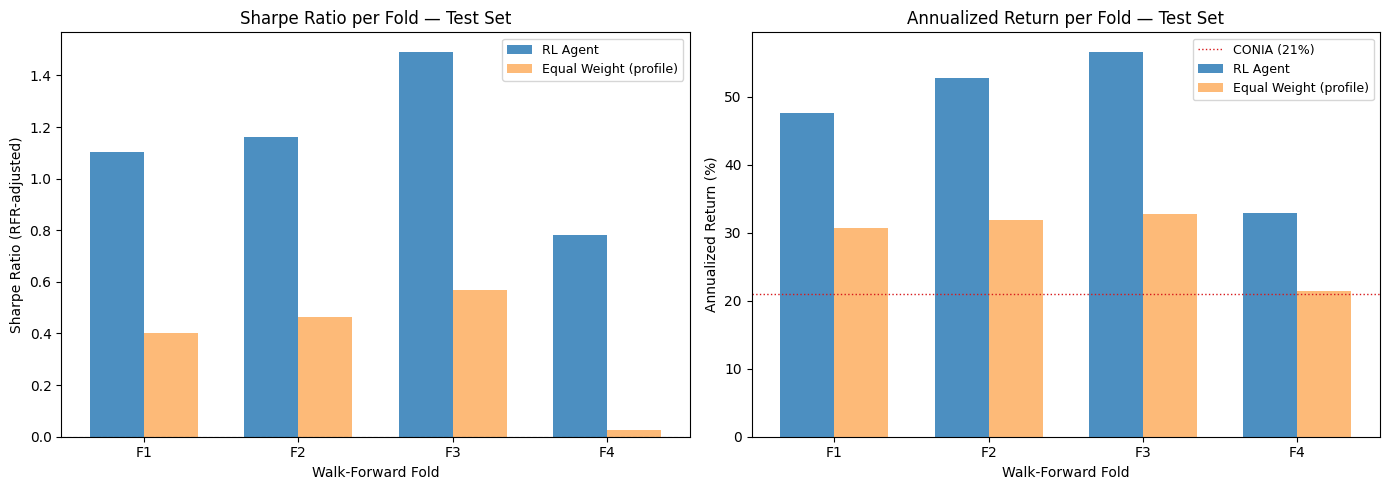


✅ Aggregate results saved to C:\Users\youssef\Desktop\Portfolio_Personalization\outputs\conservative\v3\aggregate

── Final Summary ──
RL  mean Sharpe : +1.135 ± 0.252
EQW mean Sharpe : +0.364 ± 0.205
RL  mean return : +47.5%
EQW mean return : +29.2%
RL significantly outperforms EQW   : 4/4 folds
RL significantly underperforms EQW : 0/4 folds


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

folds_list = list(all_fold_results.keys())
rl_sharpes = [all_fold_results[f]["rl_test"]["sharpe"]     for f in folds_list]
eq_sharpes = [all_fold_results[f]["eq_test"]["sharpe"]     for f in folds_list]
rl_returns = [all_fold_results[f]["rl_test"]["ann_return"] * 100 for f in folds_list]
eq_returns = [all_fold_results[f]["eq_test"]["ann_return"] * 100 for f in folds_list]

x = np.arange(len(folds_list))
w = 0.35

ax = axes[0]
ax.bar(x - w/2, rl_sharpes, width=w, color=PALETTE["primary"],  alpha=0.85, label="RL Agent")
ax.bar(x + w/2, eq_sharpes, width=w, color=PALETTE["tertiary"], alpha=0.85, label="Equal Weight (profile)")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xlabel("Walk-Forward Fold")
ax.set_ylabel("Sharpe Ratio (RFR-adjusted)")
ax.set_title("Sharpe Ratio per Fold — Test Set")
ax.set_xticks(x)
ax.set_xticklabels([f.replace("fold_", "F") for f in folds_list])
ax.legend(fontsize=9)

ax2 = axes[1]
ax2.bar(x - w/2, rl_returns, width=w, color=PALETTE["primary"],  alpha=0.85, label="RL Agent")
ax2.bar(x + w/2, eq_returns, width=w, color=PALETTE["tertiary"], alpha=0.85, label="Equal Weight (profile)")
ax2.axhline(ANNUAL_RISK_FREE_RATE * 100, color=PALETTE["alert"],
            linewidth=1.0, linestyle=":", label=f"CONIA ({ANNUAL_RISK_FREE_RATE*100:.0f}%)")
ax2.set_xlabel("Walk-Forward Fold")
ax2.set_ylabel("Annualized Return (%)")
ax2.set_title("Annualized Return per Fold — Test Set")
ax2.set_xticks(x)
ax2.set_xticklabels([f.replace("fold_", "F") for f in folds_list])
ax2.legend(fontsize=9)

plt.tight_layout()
agg_plots_dir = BASE_DIR / "outputs" / RISK_PROFILE / VERSION / "aggregate"
agg_plots_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(agg_plots_dir / "fold_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

agg_summary = {
    "n_folds":           len(WALK_FORWARD_FOLDS),
    "risk_profile":      RISK_PROFILE,
    "version":           VERSION,
    "market_signal":     meta.get("market_signal", "egx30_ma_ratio + conia_delta"),
    "dynamic_filtering": "Design B — profile_mask_tensor, N=31 fixed",
    "folds":             [f["name"] for f in WALK_FORWARD_FOLDS],
    "rl_mean_sharpe":    float(np.mean(rl_sharpes)),
    "rl_std_sharpe":     float(np.std(rl_sharpes)),
    "eq_mean_sharpe":    float(np.mean(eq_sharpes)),
    "eq_std_sharpe":     float(np.std(eq_sharpes)),
    "rl_mean_return":    float(np.mean(rl_returns)),
    "eq_mean_return":    float(np.mean(eq_returns)),
    "n_outperforms":     int(n_outperforms),
    "n_underperforms":   int(n_underperforms),
}
json.dump(agg_summary,
          open(agg_plots_dir / "aggregate_summary.json", "w"), indent=2)

print(f"\n✅ Aggregate results saved to {agg_plots_dir.resolve()}")
print(f"\n── Final Summary ──")
print(f"RL  mean Sharpe : {agg_summary['rl_mean_sharpe']:+.3f} ± {agg_summary['rl_std_sharpe']:.3f}")
print(f"EQW mean Sharpe : {agg_summary['eq_mean_sharpe']:+.3f} ± {agg_summary['eq_std_sharpe']:.3f}")
print(f"RL  mean return : {agg_summary['rl_mean_return']:+.1f}%")
print(f"EQW mean return : {agg_summary['eq_mean_return']:+.1f}%")
print(f"RL significantly outperforms EQW   : "
      f"{n_outperforms}/{len(WALK_FORWARD_FOLDS)} folds")
print(f"RL significantly underperforms EQW : "
      f"{n_underperforms}/{len(WALK_FORWARD_FOLDS)} folds")

In [29]:
# Signal↔cash correlation diagnostic
for fold_name, result in all_fold_results.items():
    split = fold_split_indices[fold_name]
    model = fold_models[fold_name]
    test_ep_len = 16 if fold_name == "fold_4" else EPISODE_LENGTH

    eval_env = PortfolioEnv(
        feature_tensor      = feature_tensor,
        returns_tensor      = returns_tensor,
        mask_tensor         = mask_tensor,
        market_signal       = market_signal,
        profile_mask_tensor = profile_mask_tensor,
        universe_indices    = universe_indices,
        split_indices       = split,
        risk_profile        = RISK_PROFILE,
        feature_names       = feature_names,
        mode                = "test",
        episode_length      = test_ep_len,
        rebalance_days      = REBALANCE_DAYS,
        silent              = True,
    )

    signals, cash_weights = [], []
    obs, _ = eval_env.reset()
    for _ in range(test_ep_len):
        action, _ = model.predict(obs, deterministic=True)
        obs, _, _, truncated, info = eval_env.step(action)
        day_idx = eval_env.start_idx + (eval_env.current_step - 1) * REBALANCE_DAYS
        signals.append(float(market_signal[day_idx, 0]))
        cash_weights.append(info["current_weights"][-1])
        if truncated:
            break

    corr = np.corrcoef(signals, cash_weights)[0, 1]
    print(f"{fold_name}: signal↔cash correlation = {corr:+.3f}  "
          f"({'✓ using signal' if corr < -0.1 else '✗ not using signal'})")

fold_1: signal↔cash correlation = -0.580  (✓ using signal)
fold_2: signal↔cash correlation = -0.465  (✓ using signal)


fold_3: signal↔cash correlation = -0.284  (✓ using signal)
fold_4: signal↔cash correlation = +0.028  (✗ not using signal)
